# Discrete Time Fourier Transform (DTFT) and FFT for EEG Analysis

This notebook demonstrates Chapter 11 frequency-domain concepts on two signals:
1. A simulated EEG-like signal (known sine components + noise)
2. A real preprocessed EEG segment exported from preprocessing.ipynb

We will:
- Implement a manual DTFT using complex exponentials (Euler's formula)
- Compute the same transform with NumPy FFT
- Verify DTFT and FFT equivalence
- Reconstruct the signal with IFFT and quantify reconstruction error
- Plot correctly scaled one-sided amplitude spectra up to Nyquist

In [255]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(7)

def manual_dtft(x: np.ndarray) -> np.ndarray:
    """Compute DTFT/DFT coefficients manually via dot products with e^{-i2pi kn/N}."""
    x = np.asarray(x, dtype=float)
    N = len(x)
    X = np.zeros(N, dtype=complex)
    n = np.arange(N)

    for k in range(N):
        complex_sine = np.exp(-1j * 2 * np.pi * k * n / N)
        X[k] = np.sum(x * complex_sine)

    return X

def one_sided_amplitude(X: np.ndarray, N: int) -> np.ndarray:
    """Return correctly scaled one-sided amplitude spectrum (DC..Nyquist)."""
    amp = np.abs(X) / N
    n_unique = N // 2 + 1
    amp_one = amp[:n_unique].copy()

    # Double non-DC and non-Nyquist bins for one-sided representation.
    if N % 2 == 0:
        amp_one[1:-1] *= 2
    else:
        amp_one[1:] *= 2

    return amp_one

def analyze_signal(x: np.ndarray, fs: float, label: str, use_manual_dtft: bool = True):
    N = len(x)
    t = np.arange(N) / fs
    freqs = np.arange(N // 2 + 1) * fs / N

    if use_manual_dtft and N <= 2048:
        X = manual_dtft(x)
    else:
        X = np.fft.fft(x)

    max_coeff_diff = np.max(np.abs(X - np.fft.fft(x)))

    x_ifft = np.fft.ifft(X)
    max_recon_error = np.max(np.abs(x - np.real(x_ifft)))

    amp_manual = one_sided_amplitude(manual_dtft(x), N) if use_manual_dtft and N <= 2048 else one_sided_amplitude(X, N)
    amp_fft = one_sided_amplitude(np.fft.fft(x), N)
    max_amp_diff = np.max(np.abs(amp_manual - amp_fft))

    print(f"=== {label} ===")
    print(f"N = {N}, fs = {fs:.2f} Hz, Nyquist = {fs/2:.2f} Hz")
    print(f"DC component (manual) = {X[0]:.6f}")
    print(f"Max |DTFT - FFT| = {max_coeff_diff:.3e}")
    print(f"Max one-sided amplitude difference = {max_amp_diff:.3e}")
    print(f"Max IFFT reconstruction error = {max_recon_error:.3e}")
    print()

    return {
        "t": t,
        "freqs": freqs,
        "X_manual": X,
        "X_fft": np.fft.fft(x),
        "x_ifft": x_ifft,
        "amp_manual": amp_manual,
        "amp_fft": amp_fft,
        "max_coeff_diff": max_coeff_diff,
        "max_recon_error": max_recon_error,
    }

## Part A1: Simulated EEG-Like Signal (1 second at 1000 Hz)

Theory mapping:
- Signal model uses sums of sinusoids: A sin(2 pi f t + theta)
- DTFT computes dot products with complex waves e^{-i2 pi kn/N}
- k = 0 is the DC component (mean offset)
- Unique positive-frequency bins are N/2 + 1 (Nyquist included)


=== Simulated Signal A1 ===
N = 1000, fs = 1000.00 Hz, Nyquist = 500.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 1.923e-10
Max one-sided amplitude difference = 4.494e-14
Max IFFT reconstruction error = 8.760e-13



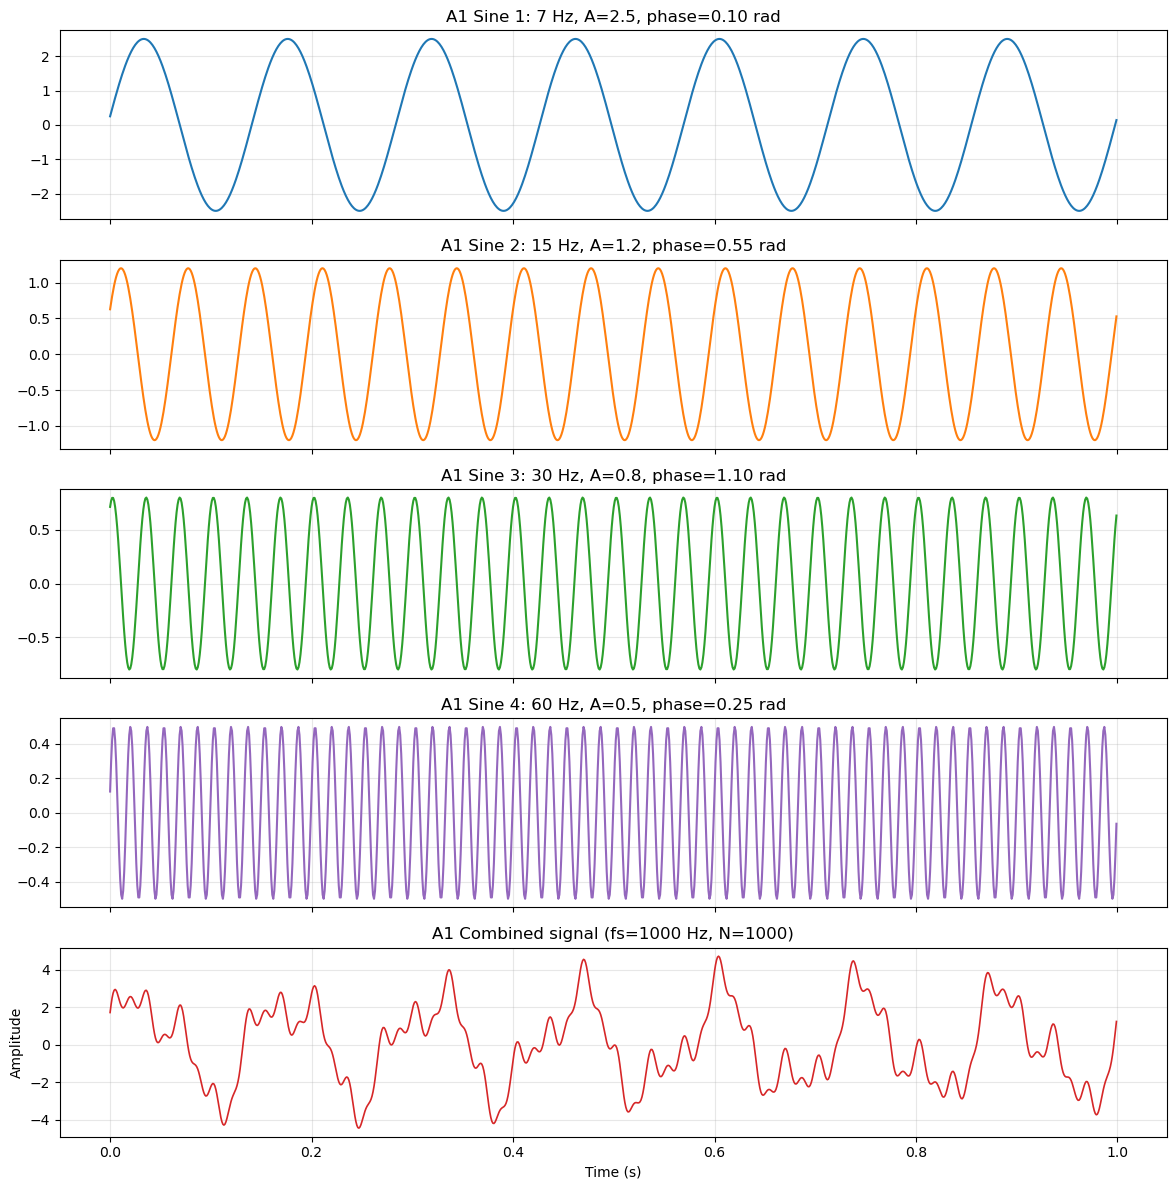

In [256]:
# pylint: disable=invalid-name

# Generate 1 second of data at 1000 Hz
fs_sim = 1000
DURATION_SIM = 1.0
N_SIM = int(fs_sim * DURATION_SIM)
t_sim = np.arange(N_SIM) / fs_sim

# frequencies, amplitudes, and phases for the simulated signal
# Ground-truth components
f1, a1, p1 = 7, 2.5, 0.10   # phase in radians
f2, a2, p2 = 15, 1.2, 0.55   # phase in radians
f3, a3, p3 = 30, 0.8, 1.10   # phase in radians
f4, a4, p4 = 60, 0.5, 0.25   # phase in radians (

s1 = a1 * np.sin(2 * np.pi * f1 * t_sim + p1)
s2 = a2 * np.sin(2 * np.pi * f2 * t_sim + p2)
s3 = a3 * np.sin(2 * np.pi * f3 * t_sim + p3)
s4 = a4 * np.sin(2 * np.pi * f4 * t_sim + p4)

x_sim_clean = s1 + s2 + s3 + s4
NOISE = np.zeros(N_SIM)  # or: 0.5 * np.random.randn(N_SIM)
x_sim = x_sim_clean + NOISE

sim_result = analyze_signal(x_sim, fs_sim, "Simulated Signal A1")

# Plot each sine and the combination, including phase information in radians
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

axes[0].plot(t_sim, s1, color="tab:blue")
axes[0].set_title(f"A1 Sine 1: {f1} Hz, A={a1}, phase={p1:.2f} rad")
axes[0].grid(alpha=0.3)

axes[1].plot(t_sim, s2, color="tab:orange")
axes[1].set_title(f"A1 Sine 2: {f2} Hz, A={a2}, phase={p2:.2f} rad")
axes[1].grid(alpha=0.3)

axes[2].plot(t_sim, s3, color="tab:green")
axes[2].set_title(f"A1 Sine 3: {f3} Hz, A={a3}, phase={p3:.2f} rad")
axes[2].grid(alpha=0.3)

axes[3].plot(t_sim, s4, color="tab:purple")
axes[3].set_title(f"A1 Sine 4: {f4} Hz, A={a4}, phase={p4:.2f} rad")
axes[3].grid(alpha=0.3)

axes[4].plot(t_sim, x_sim, color="tab:red", linewidth=1.2)
axes[4].set_title(f"A1 Combined signal (fs={fs_sim} Hz, N={N_SIM})")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Amplitude")
axes[4].grid(alpha=0.3)


plt.tight_layout()
plt.show()

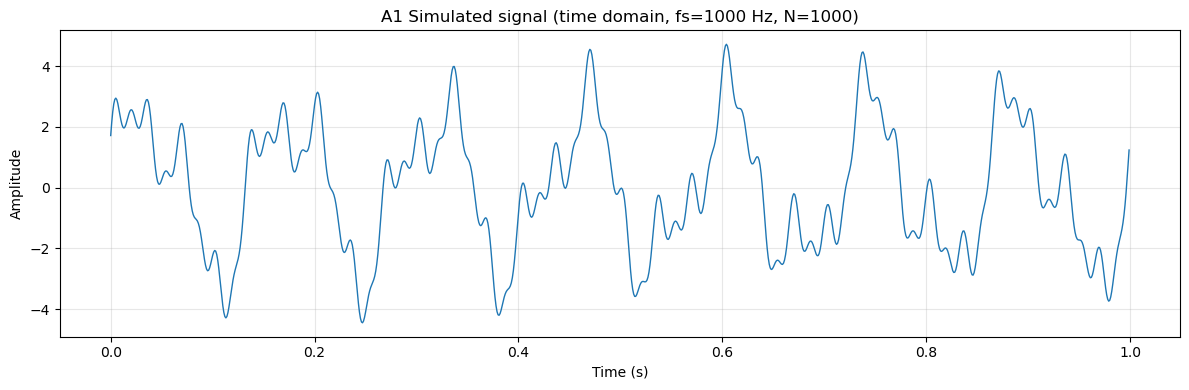

Top spectral peaks (A1 simulated signal):
  f =   7.00 Hz, amp = 2.500
  f =  15.00 Hz, amp = 1.200
  f =  30.00 Hz, amp = 0.800
  f =  60.00 Hz, amp = 0.500
  f =  31.00 Hz, amp = 0.000
  f =  29.00 Hz, amp = 0.000
  f =  14.00 Hz, amp = 0.000
  f =  61.00 Hz, amp = 0.000


In [257]:
# Visualization for simulated signal
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(sim_result["t"], x_sim, color="tab:blue", linewidth=1.0)
ax.set_title(f"A1 Simulated signal (time domain, fs={fs_sim} Hz, N={N_SIM})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# Show top peaks
peak_idx = np.argsort(sim_result["amp_fft"])[-8:][::-1]
print("Top spectral peaks (A1 simulated signal):")
for idx in peak_idx:
    print(f"  f = {sim_result['freqs'][idx]:6.2f} Hz, amp = {sim_result['amp_fft'][idx]:.3f}")

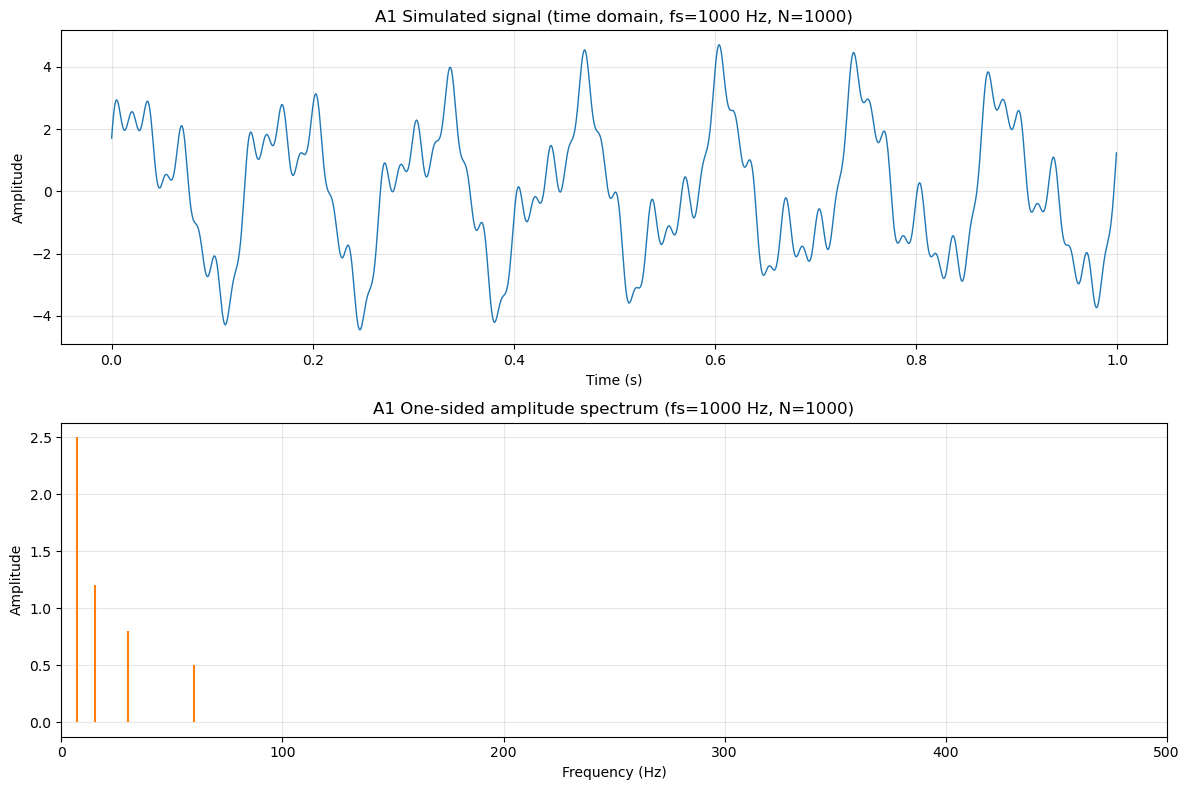

In [258]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result["t"], x_sim, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A1 Simulated signal (time domain, fs={fs_sim} Hz, N={N_SIM})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result["freqs"],
    sim_result["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_sim / 2)
axes[1].set_title(f"A1 One-sided amplitude spectrum (fs={fs_sim} Hz, N={N_SIM})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

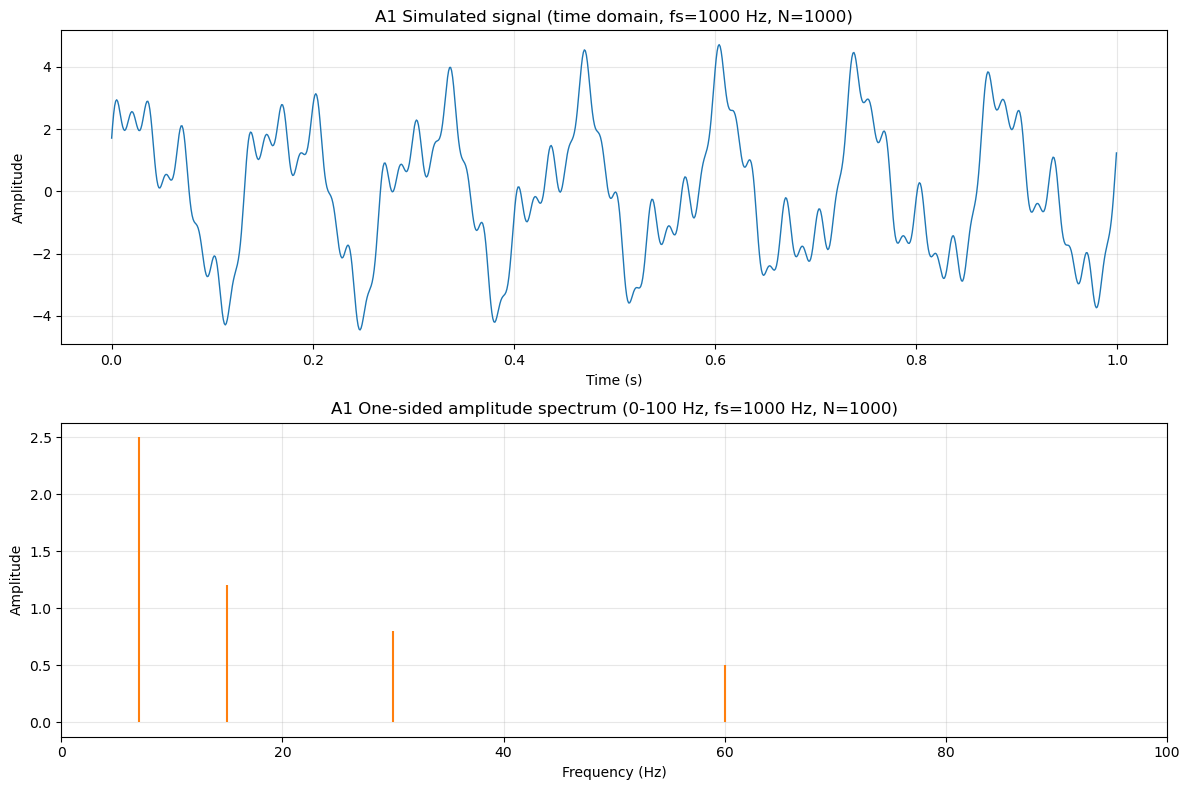

In [259]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result["t"], x_sim, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A1 Simulated signal (time domain, fs={fs_sim} Hz, N={N_SIM})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result["freqs"],
    sim_result["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, 100)
axes[1].set_title(f"A1 One-sided amplitude spectrum (0-100 Hz, fs={fs_sim} Hz, N={N_SIM})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

A1 Phase per bin (first 15 one-sided bins):
  k= 0, f=  0.00 Hz, phase= 0.000 rad
  k= 1, f=  1.00 Hz, phase=-1.982 rad
  k= 2, f=  2.00 Hz, phase= 1.222 rad
  k= 3, f=  3.00 Hz, phase=-3.017 rad
  k= 4, f=  4.00 Hz, phase= 2.034 rad
  k= 5, f=  5.00 Hz, phase= 1.571 rad
  k= 6, f=  6.00 Hz, phase=-2.356 rad
  k= 7, f=  7.00 Hz, phase=-1.471 rad
  k= 8, f=  8.00 Hz, phase= 2.678 rad
  k= 9, f=  9.00 Hz, phase= 1.736 rad
  k=10, f= 10.00 Hz, phase= 2.928 rad
  k=11, f= 11.00 Hz, phase= 2.345 rad
  k=12, f= 12.00 Hz, phase= 3.142 rad
  k=13, f= 13.00 Hz, phase= 3.058 rad
  k=14, f= 14.00 Hz, phase= 1.800 rad


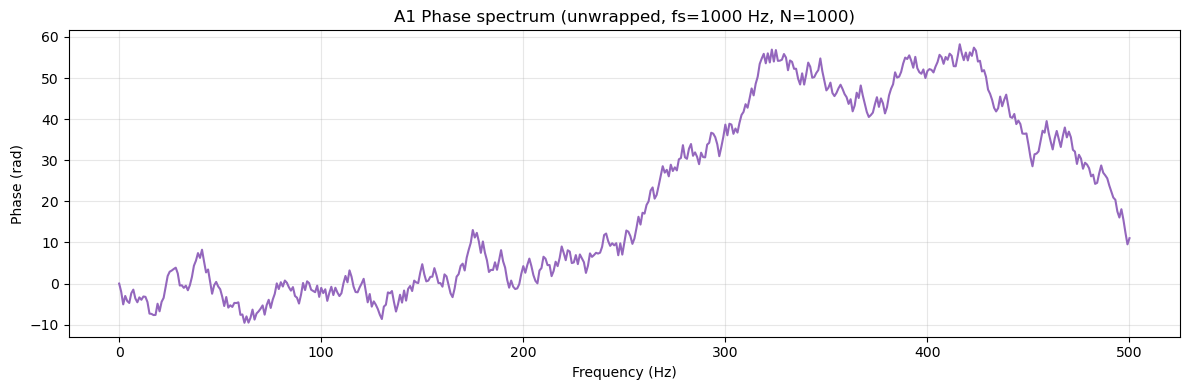

In [260]:
# Phase spectrum and phase per bin (simulated signal)
X_sim = sim_result["X_manual"]
freqs_sim = sim_result["freqs"]
N_sim = len(X_sim)
n_unique = N_sim // 2 + 1

phase_bins = np.angle(X_sim[:n_unique])
phase_unwrapped = np.unwrap(phase_bins)

print("A1 Phase per bin (first 15 one-sided bins):")
for k in range(15):
    print(f"  k={k:2d}, f={freqs_sim[k]:6.2f} Hz, phase={phase_bins[k]: .3f} rad")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs_sim, phase_unwrapped, color="tab:purple")
ax.set_title(f"A1 Phase spectrum (unwrapped, fs={fs_sim} Hz, N={N_sim})")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Phase (rad)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [261]:
# Plot phases of the top spectral peaks only

x = x_sim_clean
N = len(x)

X = np.fft.fft(x)
2000
ax.stem(freqs[peak_idx], phase[peak_idx], basefmt=" ", linefmt="tab:purple", markerfmt="o")
ax.set_title(f"A1 Phase of Top Spectral Peaks (fs={fs_sim} Hz, N={N})")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Phase (rad)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for idx in peak_idx:
    print(f"A1 f = {freqs[idx]:.2f} Hz, phase = {phase[idx]:.3f} rad, amp = {amp[idx]:.3f}")

<Figure size 640x480 with 0 Axes>

A1 f = 7.00 Hz, phase = -1.471 rad, amp = 2.500
A1 f = 15.00 Hz, phase = -1.021 rad, amp = 1.200
A1 f = 30.00 Hz, phase = -0.471 rad, amp = 0.800
A1 f = 60.00 Hz, phase = -1.321 rad, amp = 0.500
A1 f = 31.00 Hz, phase = -0.396 rad, amp = 0.000
A1 f = 29.00 Hz, phase = 2.453 rad, amp = 0.000
A1 f = 14.00 Hz, phase = 2.158 rad, amp = 0.000
A1 f = 61.00 Hz, phase = -1.196 rad, amp = 0.000


In [262]:
# Compare DFT-based phase, add pi/2, and compare to generating phases for each simulated component
N = len(x_sim_clean)
X = np.fft.fft(x_sim_clean)
phase = np.angle(X[: N // 2 + 1])
phase_plus = (phase + np.pi / 2 + np.pi) % (2 * np.pi) - np.pi  # wrap to [-pi, pi]

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

components = [(f1, p1), (f2, p2), (f3, p3), (f4, p4)]

print("freq Hz | bin | init_phase (rad) | fft_phase (rad) | fft+pi/2 (rad) | (fft+pi/2)-init (rad)")
for f, p in components:
    k = int(np.round(f * N / fs_sim))
    diff = wrap_pi(phase_plus[k] - p)
    print(f"{f:7.2f} | {k:3d} | {p:15.3f} | {phase[k]:13.3f} | {phase_plus[k]:13.3f} | {diff:18.3f}")

freq Hz | bin | init_phase (rad) | fft_phase (rad) | fft+pi/2 (rad) | (fft+pi/2)-init (rad)
   7.00 |   7 |           0.100 |        -1.471 |         0.100 |             -0.000
  15.00 |  15 |           0.550 |        -1.021 |         0.550 |             -0.000
  30.00 |  30 |           1.100 |        -0.471 |         1.100 |             -0.000
  60.00 |  60 |           0.250 |        -1.321 |         0.250 |             -0.000


## Part A2: Simulated Signal (fs = 1500 Hz, N = 1000)

Repeat Part A with a different sampling rate and sample count. The duration is $N/f_s$.


=== Simulated Signal A2 ===
N = 980, fs = 1500.00 Hz, Nyquist = 750.00 Hz
DC component (manual) = 164.517672+0.000000j
Max |DTFT - FFT| = 3.464e-10
Max one-sided amplitude difference = 5.101e-14
Max IFFT reconstruction error = 1.203e-12



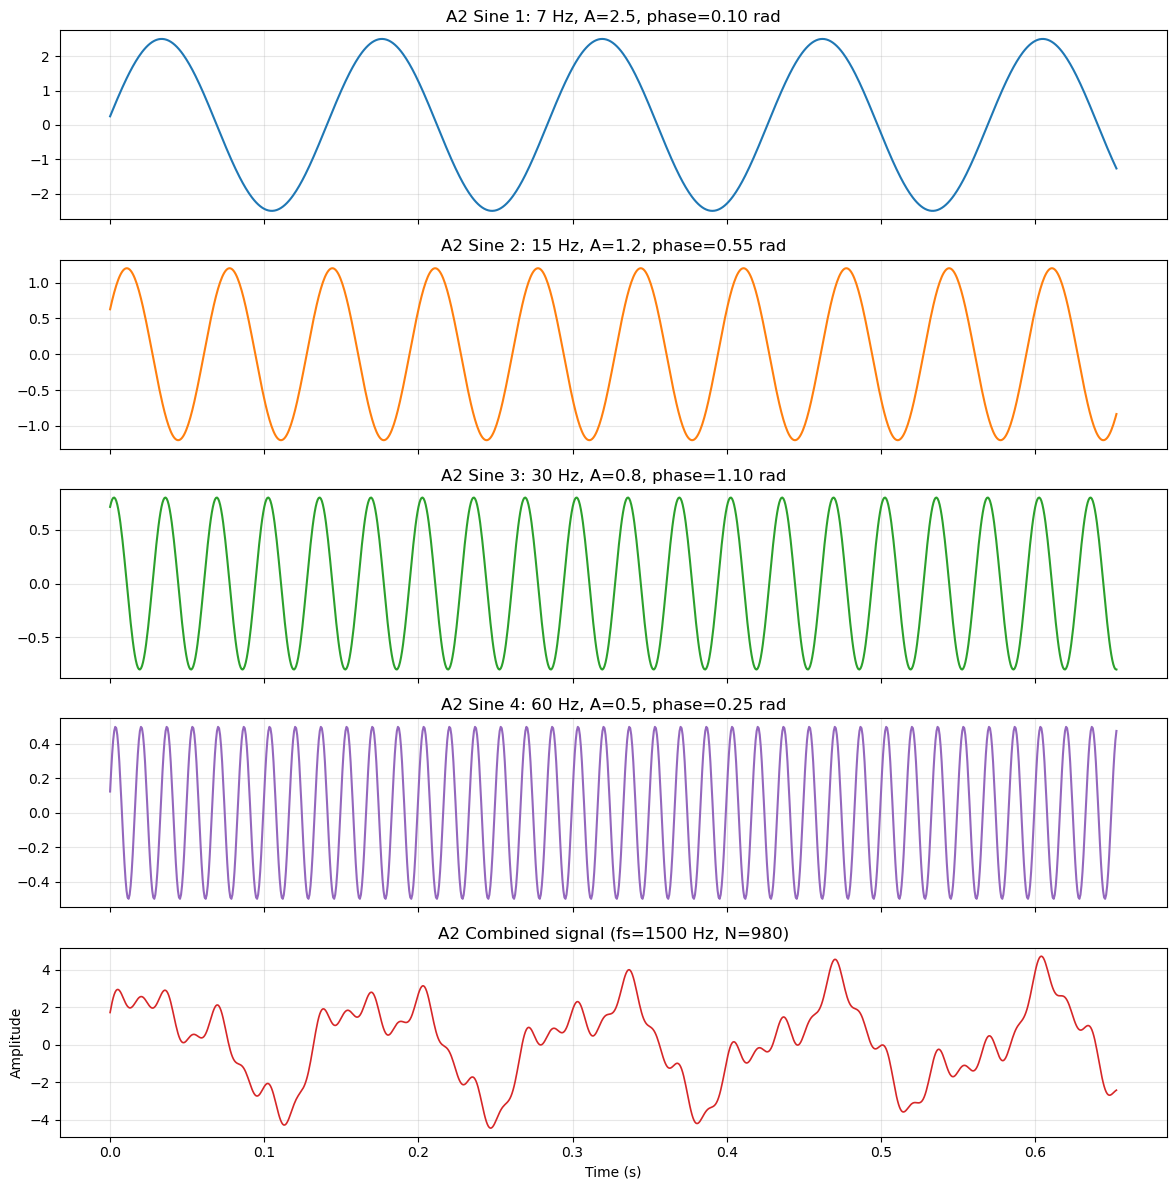

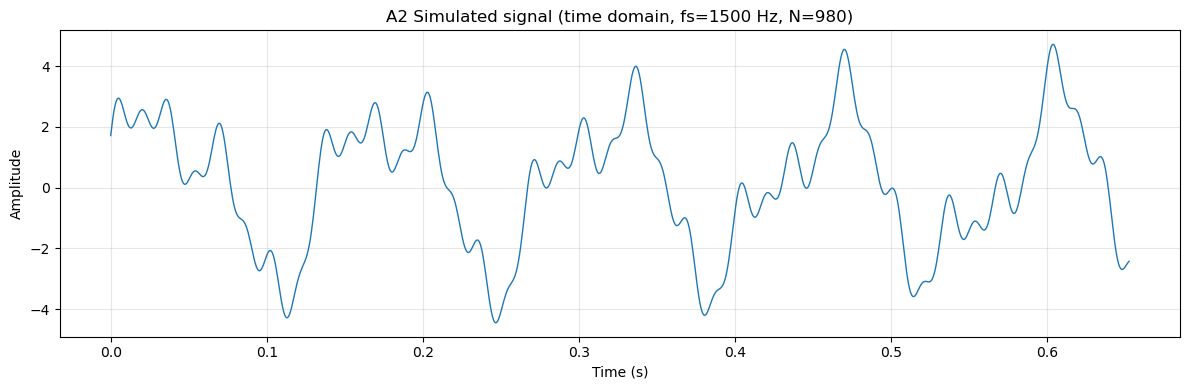

Top spectral peaks (A2 simulated signal):
  f =   7.65 Hz, amp = 1.724
  f =   6.12 Hz, amp = 1.447
  f =  15.31 Hz, amp = 1.189
  f =  30.61 Hz, amp = 0.670
  f =   4.59 Hz, amp = 0.596
  f =  59.69 Hz, amp = 0.494
  f =   9.18 Hz, amp = 0.451
  f =   3.06 Hz, amp = 0.418
A2 leakage fraction (energy outside top 4 peaks): 0.197


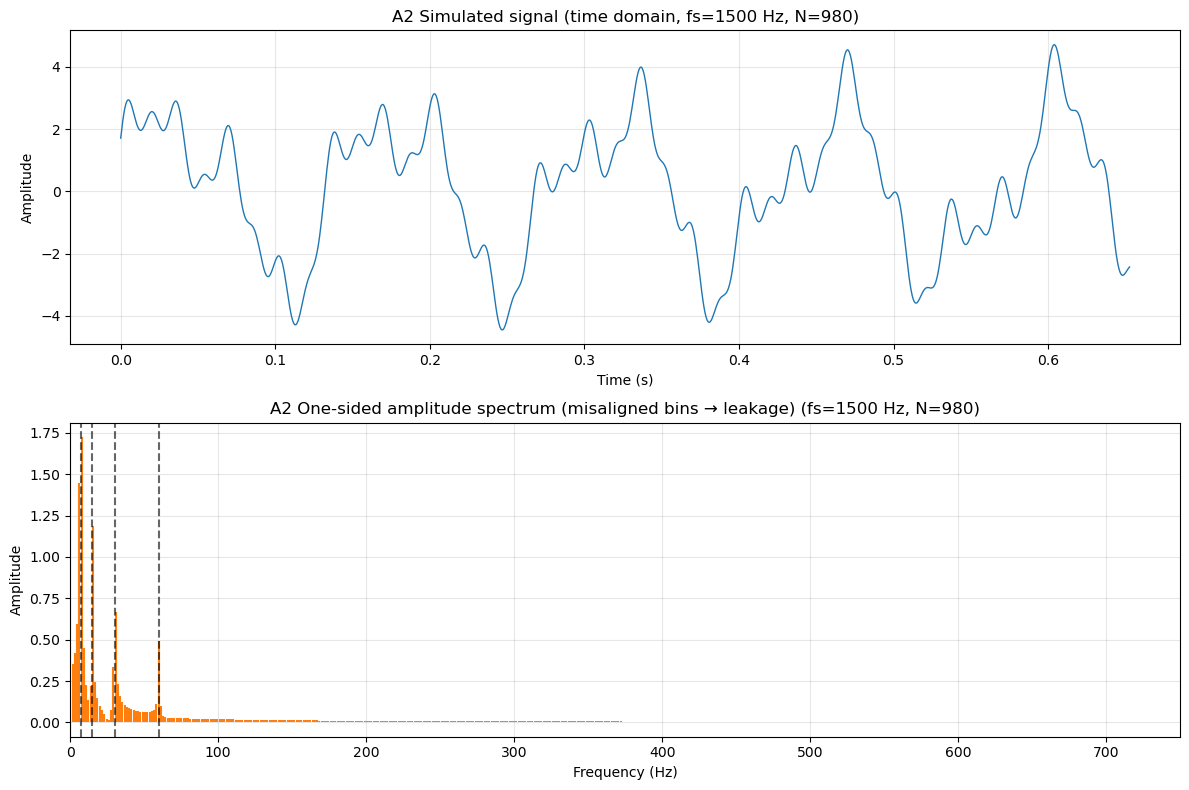

In [263]:
# Part A2: generate signal with fs=1500 Hz, N=1000
# Demonstrates baseline frequency misalignment -> spectral leakage
fs_sim_a2 = 1500
N_sim_a2 = 980
t_sim_a2 = np.arange(N_sim_a2) / fs_sim_a2

s1_a2 = a1 * np.sin(2 * np.pi * f1 * t_sim_a2 + p1)
s2_a2 = a2 * np.sin(2 * np.pi * f2 * t_sim_a2 + p2)
s3_a2 = a3 * np.sin(2 * np.pi * f3 * t_sim_a2 + p3)
s4_a2 = a4 * np.sin(2 * np.pi * f4 * t_sim_a2 + p4)

x_sim_clean_a2 = s1_a2 + s2_a2 + s3_a2 + s4_a2
noise_a2 = np.zeros(N_sim_a2)
x_sim_a2 = x_sim_clean_a2 + noise_a2

sim_result_a2 = analyze_signal(x_sim_a2, fs_sim_a2, "Simulated Signal A2")

# Plot each sine and the combination
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(t_sim_a2, s1_a2, color="tab:blue")
axes[0].set_title(f"A2 Sine 1: {f1} Hz, A={a1}, phase={p1:.2f} rad")
axes[0].grid(alpha=0.3)

axes[1].plot(t_sim_a2, s2_a2, color="tab:orange")
axes[1].set_title(f"A2 Sine 2: {f2} Hz, A={a2}, phase={p2:.2f} rad")
axes[1].grid(alpha=0.3)

axes[2].plot(t_sim_a2, s3_a2, color="tab:green")
axes[2].set_title(f"A2 Sine 3: {f3} Hz, A={a3}, phase={p3:.2f} rad")
axes[2].grid(alpha=0.3)

axes[3].plot(t_sim_a2, s4_a2, color="tab:purple")
axes[3].set_title(f"A2 Sine 4: {f4} Hz, A={a4}, phase={p4:.2f} rad")
axes[3].grid(alpha=0.3)

axes[4].plot(t_sim_a2, x_sim_a2, color="tab:red", linewidth=1.2)
axes[4].set_title(f"A2 Combined signal (fs={fs_sim_a2} Hz, N={N_sim_a2})")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Amplitude")
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Time-domain view and top peaks
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_result_a2["t"], x_sim_a2, color="tab:blue", linewidth=1.0)
ax.set_title(f"A2 Simulated signal (time domain, fs={fs_sim_a2} Hz, N={N_sim_a2})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_idx_a2 = np.argsort(sim_result_a2["amp_fft"])[-8:][::-1]
print("Top spectral peaks (A2 simulated signal):")
for idx in peak_idx_a2:
    print(f"  f = {sim_result_a2['freqs'][idx]:6.2f} Hz, amp = {sim_result_a2['amp_fft'][idx]:.3f}")

# Time + amplitude spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(sim_result_a2["t"], x_sim_a2, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A2 Simulated signal (time domain, fs={fs_sim_a2} Hz, N={N_sim_a2})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a2["freqs"],
    sim_result_a2["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_sim_a2 / 2)
axes[1].set_title(f"A2 One-sided amplitude spectrum (misaligned bins → leakage) (fs={fs_sim_a2} Hz, N={N_sim_a2})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

# Mark the generating frequencies to show misalignment vs FFT bins
for f in (f1, f2, f3, f4):
    axes[1].axvline(f, color="k", linestyle="--", alpha=0.6)

# Simple leakage metric: fraction of energy outside the top peaks
peak_idx_a2 = np.argsort(sim_result_a2["amp_fft"])[-4:][::-1]
energy_total = np.sum(sim_result_a2["amp_fft"] ** 2)
energy_peaks = np.sum(sim_result_a2["amp_fft"][peak_idx_a2] ** 2)
leak_fraction = 1 - energy_peaks / (energy_total + 1e-12)
print(f"A2 leakage fraction (energy outside top 4 peaks): {leak_fraction:.3f}")
plt.tight_layout()
plt.show()

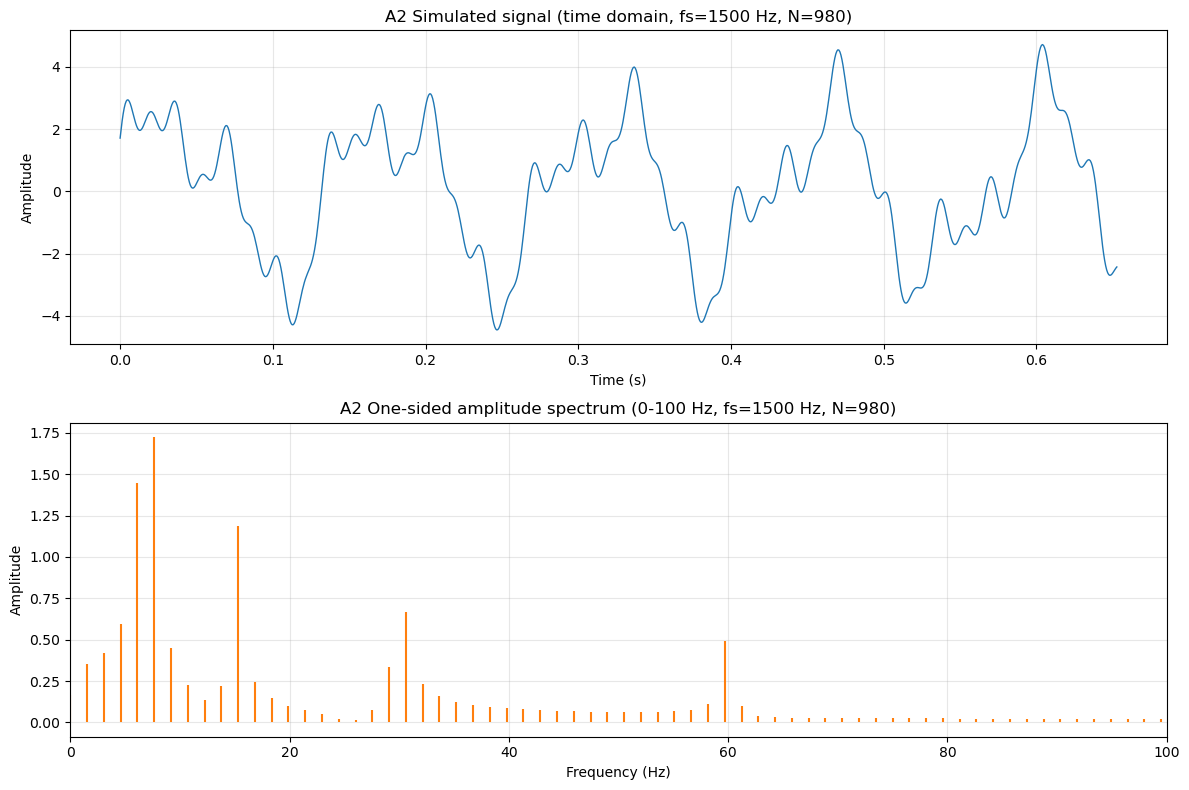

In [264]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result_a2["t"], x_sim_a2, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A2 Simulated signal (time domain, fs={fs_sim_a2} Hz, N={N_sim_a2})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a2["freqs"],
    sim_result_a2["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, 100)
axes[1].set_title(f"A2 One-sided amplitude spectrum (0-100 Hz, fs={fs_sim_a2} Hz, N={N_sim_a2})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part A3: Simulated Signal (fs = 1200 Hz, N = 3000)

Repeat Part A with another different sampling rate and sample count. The duration is $N/f_s = 3000/1200 = 2.5$ seconds.

=== Simulated Signal A3 ===
N = 4096, fs = 1500.00 Hz, Nyquist = 750.00 Hz
DC component (manual) = 22.541413+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 2.665e-15



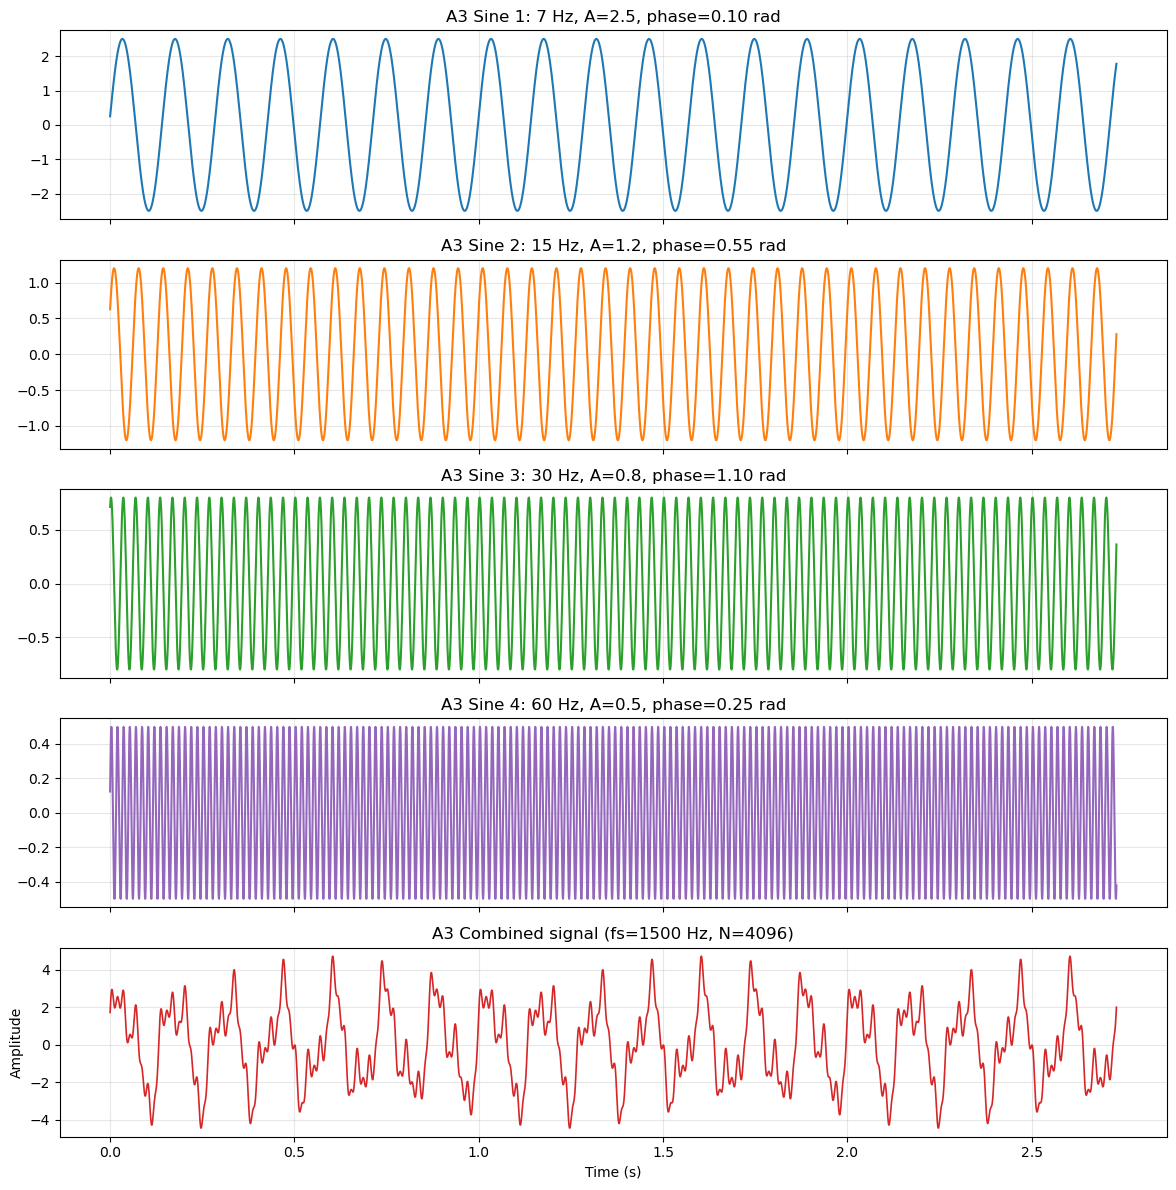

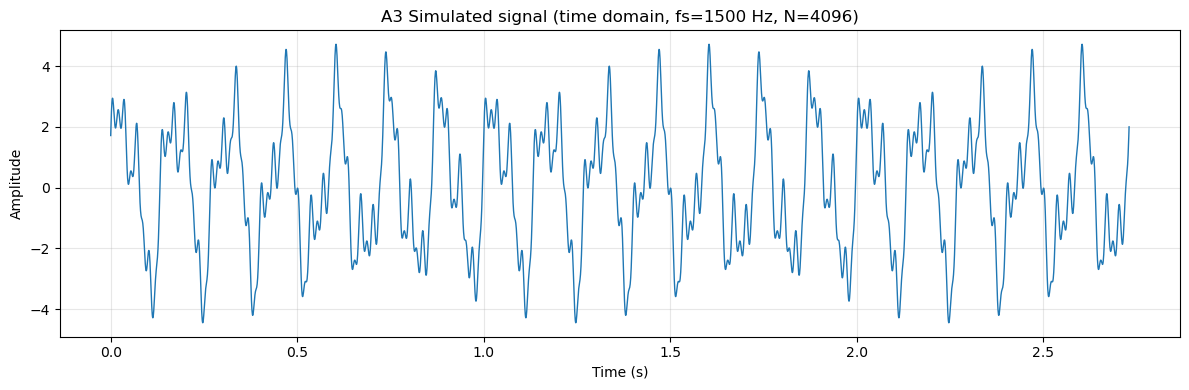

Top spectral peaks (A3 simulated signal):
  f =   6.96 Hz, amp = 2.439
  f =  15.01 Hz, amp = 1.180
  f =  30.03 Hz, amp = 0.788
  f =  60.06 Hz, amp = 0.478
  f =   7.32 Hz, amp = 0.324
  f =   6.59 Hz, amp = 0.245
  f =   7.69 Hz, amp = 0.156
  f =   6.23 Hz, amp = 0.126
A3 leakage fraction (energy outside top 4 peaks): 0.036


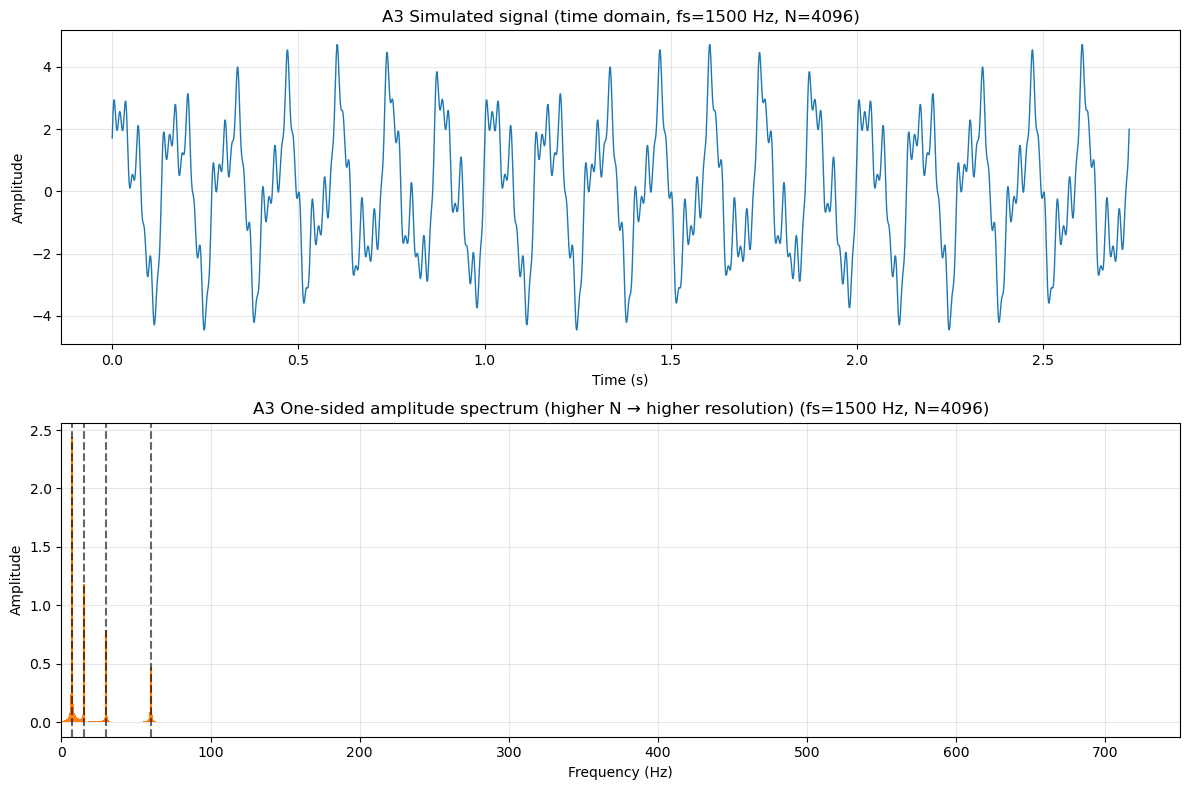

In [265]:
# Part A3: generate signal with fs=1500 Hz, N=3000
# Demonstrates increasing N (longer duration) at same fs -> higher frequency resolution
fs_sim_a3 = 1500
N_sim_a3 = 4096
t_sim_a3 = np.arange(N_sim_a3) / fs_sim_a3

s1_a3 = a1 * np.sin(2 * np.pi * f1 * t_sim_a3 + p1)
s2_a3 = a2 * np.sin(2 * np.pi * f2 * t_sim_a3 + p2)
s3_a3 = a3 * np.sin(2 * np.pi * f3 * t_sim_a3 + p3)
s4_a3 = a4 * np.sin(2 * np.pi * f4 * t_sim_a3 + p4)

x_sim_clean_a3 = s1_a3 + s2_a3 + s3_a3 + s4_a3
noise_a3 = np.zeros(N_sim_a3)
x_sim_a3 = x_sim_clean_a3 + noise_a3

# For larger N we avoid the manual DTFT; analyze_signal will use FFT
sim_result_a3 = analyze_signal(x_sim_a3, fs_sim_a3, "Simulated Signal A3")

# Plot each sine and the combination
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(t_sim_a3, s1_a3, color="tab:blue")
axes[0].set_title(f"A3 Sine 1: {f1} Hz, A={a1}, phase={p1:.2f} rad")
axes[0].grid(alpha=0.3)

axes[1].plot(t_sim_a3, s2_a3, color="tab:orange")
axes[1].set_title(f"A3 Sine 2: {f2} Hz, A={a2}, phase={p2:.2f} rad")
axes[1].grid(alpha=0.3)

axes[2].plot(t_sim_a3, s3_a3, color="tab:green")
axes[2].set_title(f"A3 Sine 3: {f3} Hz, A={a3}, phase={p3:.2f} rad")
axes[2].grid(alpha=0.3)

axes[3].plot(t_sim_a3, s4_a3, color="tab:purple")
axes[3].set_title(f"A3 Sine 4: {f4} Hz, A={a4}, phase={p4:.2f} rad")
axes[3].grid(alpha=0.3)

axes[4].plot(t_sim_a3, x_sim_a3, color="tab:red", linewidth=1.2)
axes[4].set_title(f"A3 Combined signal (fs={fs_sim_a3} Hz, N={N_sim_a3})")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Amplitude")
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Time-domain view and top peaks
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_result_a3["t"], x_sim_a3, color="tab:blue", linewidth=1.0)
ax.set_title(f"A3 Simulated signal (time domain, fs={fs_sim_a3} Hz, N={N_sim_a3})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_idx_a3 = np.argsort(sim_result_a3["amp_fft"])[-8:][::-1]
print("Top spectral peaks (A3 simulated signal):")
for idx in peak_idx_a3:
    print(f"  f = {sim_result_a3['freqs'][idx]:6.2f} Hz, amp = {sim_result_a3['amp_fft'][idx]:.3f}")

# Time + amplitude spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(sim_result_a3["t"], x_sim_a3, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A3 Simulated signal (time domain, fs={fs_sim_a3} Hz, N={N_sim_a3})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a3["freqs"],
    sim_result_a3["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_sim_a3 / 2)
axes[1].set_title(f"A3 One-sided amplitude spectrum (higher N → higher resolution) (fs={fs_sim_a3} Hz, N={N_sim_a3})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

# Mark generating frequencies
for f in (f1, f2, f3, f4):
    axes[1].axvline(f, color="k", linestyle="--", alpha=0.6)

# Leakage metric for comparison
peak_idx_a3 = np.argsort(sim_result_a3["amp_fft"])[-4:][::-1]
energy_total = np.sum(sim_result_a3["amp_fft"] ** 2)
energy_peaks = np.sum(sim_result_a3["amp_fft"][peak_idx_a3] ** 2)
leak_fraction_a3 = 1 - energy_peaks / (energy_total + 1e-12)
print(f"A3 leakage fraction (energy outside top 4 peaks): {leak_fraction_a3:.3f}")

plt.tight_layout()
plt.show()

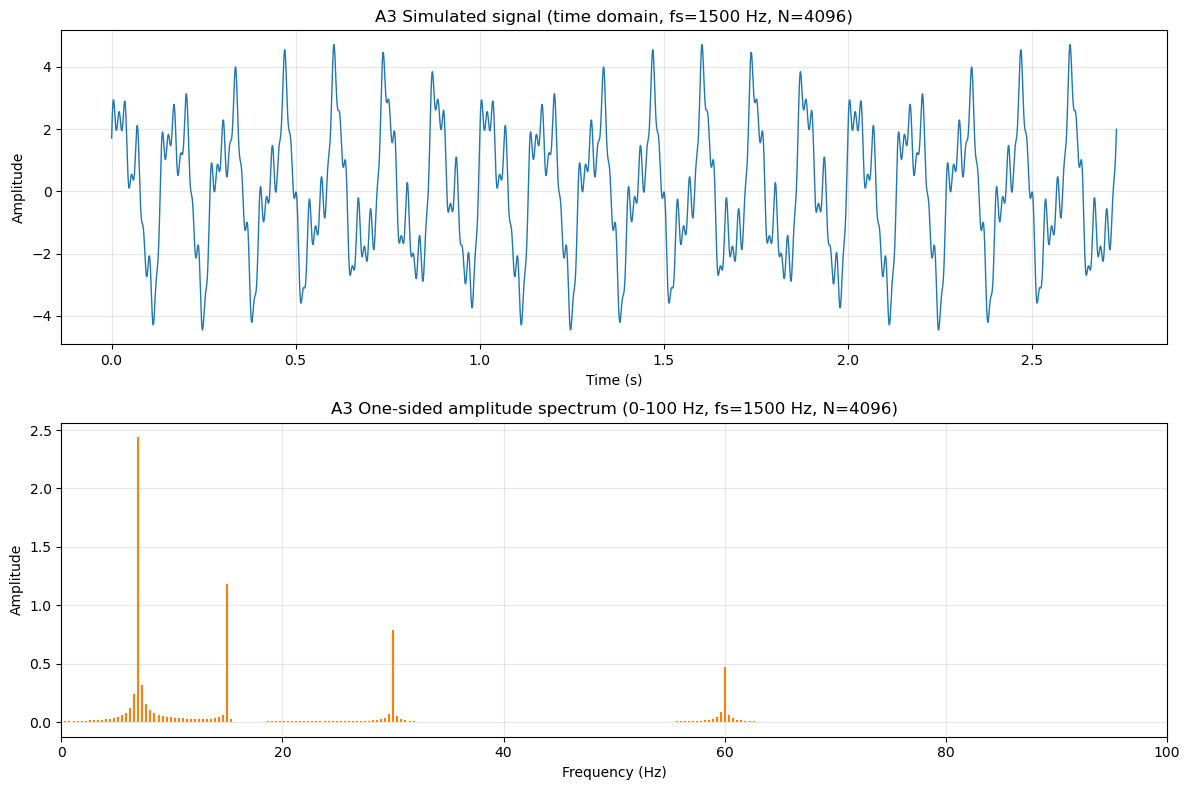

In [266]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result_a3["t"], x_sim_a3, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A3 Simulated signal (time domain, fs={fs_sim_a3} Hz, N={N_sim_a3})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a3["freqs"],
    sim_result_a3["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, 100)
axes[1].set_title(f"A3 One-sided amplitude spectrum (0-100 Hz, fs={fs_sim_a3} Hz, N={N_sim_a3})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part A4: Simulated Signal (fs = 3600 Hz, N = 3000)

Repeat Part A with higher sampling rate and same number of samples. The duration is $N/f_s = 3000/3600 = 0.833$ seconds.


=== Simulated Signal A4 ===
N = 4590, fs = 3000.00 Hz, Nyquist = 1500.00 Hz
DC component (manual) = 188.941045+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 3.109e-15



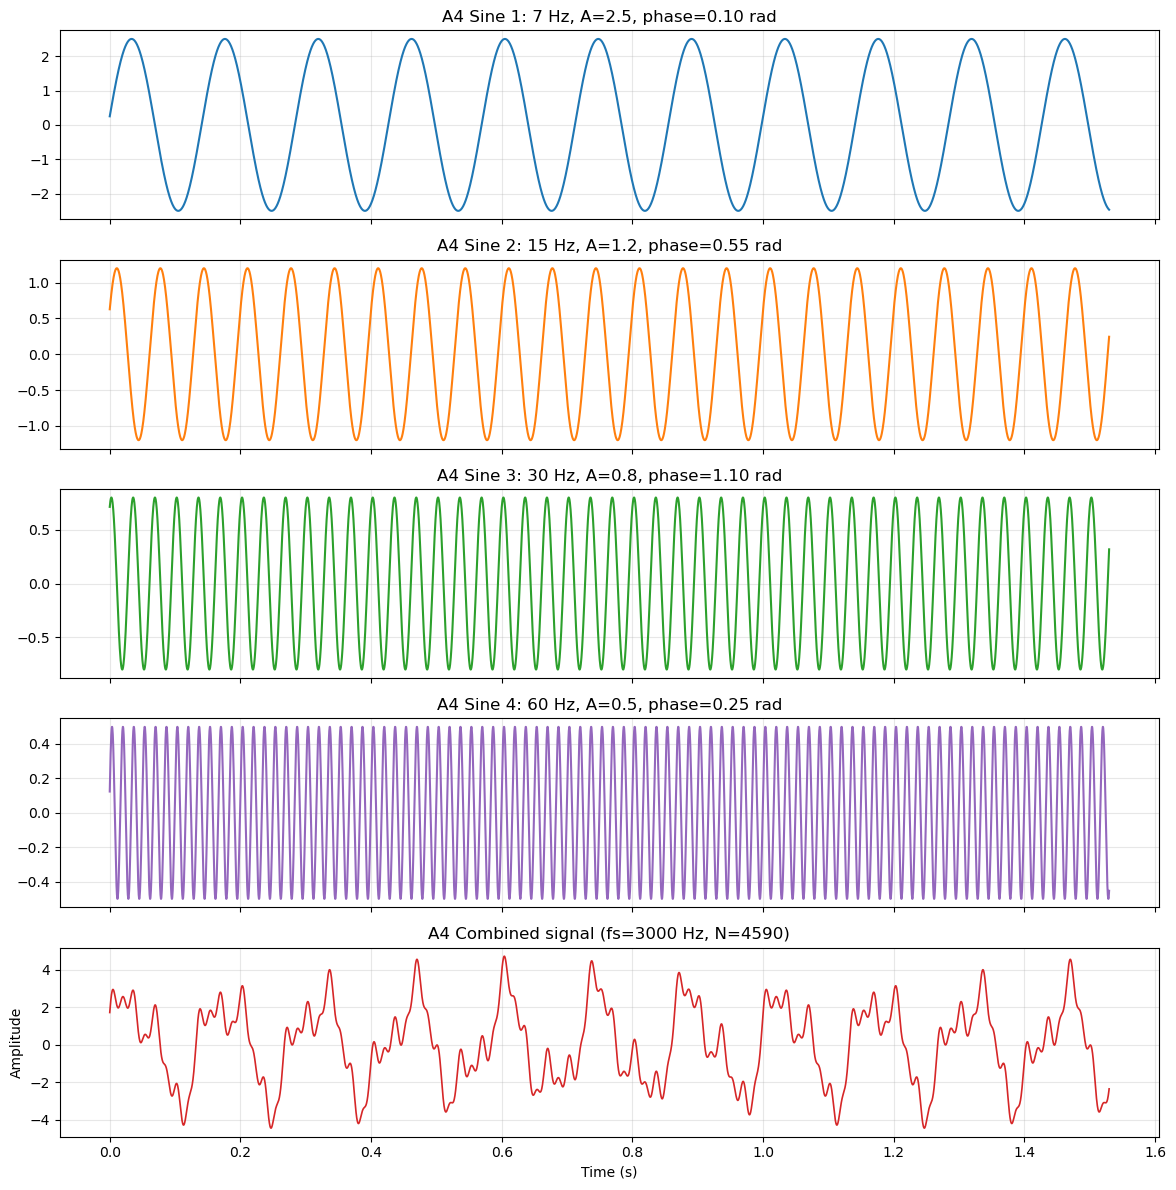

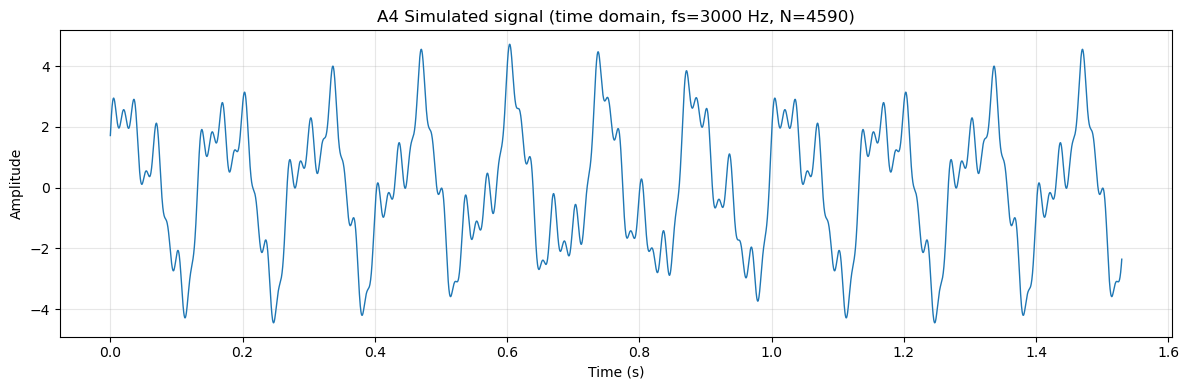

Top spectral peaks (A4 simulated signal):
  f =   7.19 Hz, amp = 2.167
  f =  15.03 Hz, amp = 1.230
  f =   6.54 Hz, amp = 0.887
  f =  30.07 Hz, amp = 0.801
  f =   7.84 Hz, amp = 0.486
  f =  60.13 Hz, amp = 0.479
  f =   5.88 Hz, amp = 0.370
  f =   8.50 Hz, amp = 0.273
A4 leakage fraction (energy outside top 4 peaks): 0.121


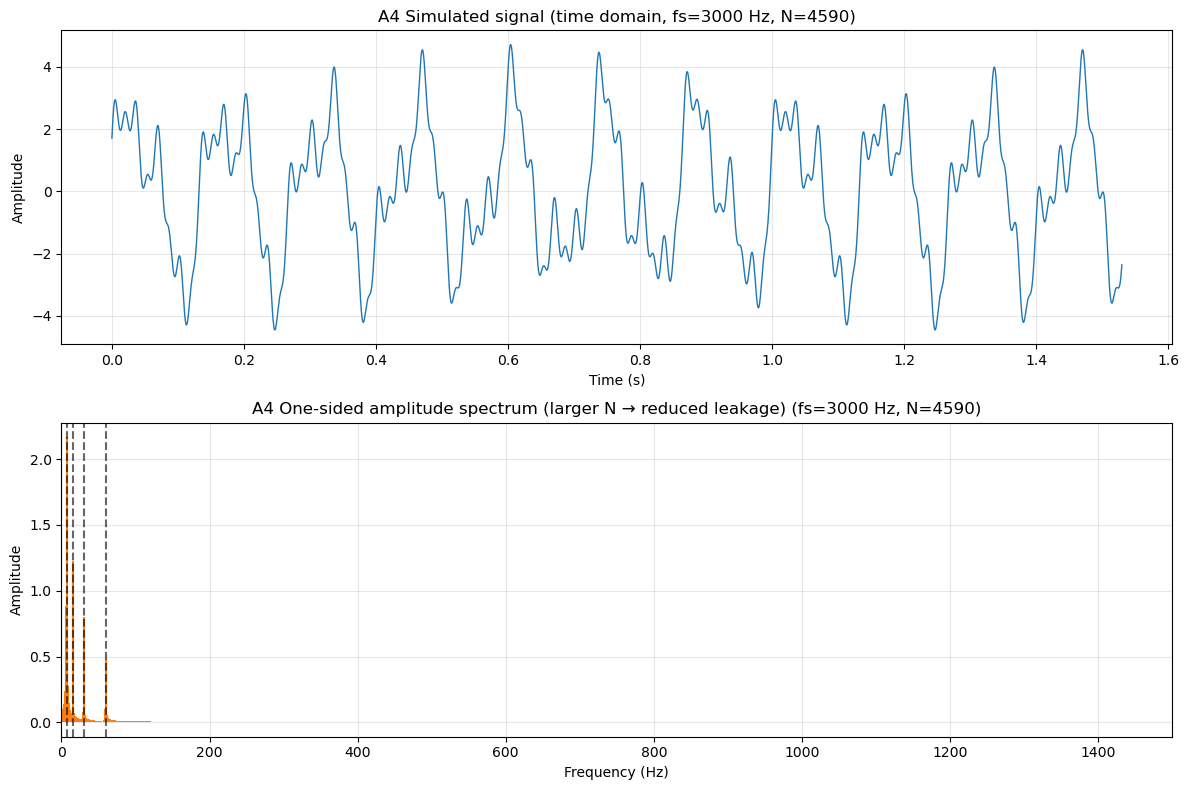

In [267]:
# Part A4: generate signal with fs=1500 Hz, N=6000
# Demonstrates increasing N further (same fs) -> reduced spectral leakage
fs_sim_a4 = 3000
N_sim_a4 = 4590
t_sim_a4 = np.arange(N_sim_a4) / fs_sim_a4

s1_a4 = a1 * np.sin(2 * np.pi * f1 * t_sim_a4 + p1)
s2_a4 = a2 * np.sin(2 * np.pi * f2 * t_sim_a4 + p2)
s3_a4 = a3 * np.sin(2 * np.pi * f3 * t_sim_a4 + p3)
s4_a4 = a4 * np.sin(2 * np.pi * f4 * t_sim_a4 + p4)

x_sim_clean_a4 = s1_a4 + s2_a4 + s3_a4 + s4_a4
noise_a4 = np.zeros(N_sim_a4)
x_sim_a4 = x_sim_clean_a4 + noise_a4

sim_result_a4 = analyze_signal(x_sim_a4, fs_sim_a4, "Simulated Signal A4")

# Plot each sine and the combination
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(t_sim_a4, s1_a4, color="tab:blue")
axes[0].set_title(f"A4 Sine 1: {f1} Hz, A={a1}, phase={p1:.2f} rad")
axes[0].grid(alpha=0.3)

axes[1].plot(t_sim_a4, s2_a4, color="tab:orange")
axes[1].set_title(f"A4 Sine 2: {f2} Hz, A={a2}, phase={p2:.2f} rad")
axes[1].grid(alpha=0.3)

axes[2].plot(t_sim_a4, s3_a4, color="tab:green")
axes[2].set_title(f"A4 Sine 3: {f3} Hz, A={a3}, phase={p3:.2f} rad")
axes[2].grid(alpha=0.3)

axes[3].plot(t_sim_a4, s4_a4, color="tab:purple")
axes[3].set_title(f"A4 Sine 4: {f4} Hz, A={a4}, phase={p4:.2f} rad")
axes[3].grid(alpha=0.3)

axes[4].plot(t_sim_a4, x_sim_a4, color="tab:red", linewidth=1.2)
axes[4].set_title(f"A4 Combined signal (fs={fs_sim_a4} Hz, N={N_sim_a4})")
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Amplitude")
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Time-domain view and top peaks
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sim_result_a4["t"], x_sim_a4, color="tab:blue", linewidth=1.0)
ax.set_title(f"A4 Simulated signal (time domain, fs={fs_sim_a4} Hz, N={N_sim_a4})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_idx_a4 = np.argsort(sim_result_a4["amp_fft"])[-8:][::-1]
print("Top spectral peaks (A4 simulated signal):")
for idx in peak_idx_a4:
    print(f"  f = {sim_result_a4['freqs'][idx]:6.2f} Hz, amp = {sim_result_a4['amp_fft'][idx]:.3f}")

# Time + amplitude spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(sim_result_a4["t"], x_sim_a4, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A4 Simulated signal (time domain, fs={fs_sim_a4} Hz, N={N_sim_a4})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a4["freqs"],
    sim_result_a4["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_sim_a4 / 2)
axes[1].set_title(f"A4 One-sided amplitude spectrum (larger N → reduced leakage) (fs={fs_sim_a4} Hz, N={N_sim_a4})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

# Mark generating frequencies
for f in (f1, f2, f3, f4):
    axes[1].axvline(f, color="k", linestyle="--", alpha=0.6)

# Leakage metric for comparison
peak_idx_a4 = np.argsort(sim_result_a4["amp_fft"])[-4:][::-1]
energy_total = np.sum(sim_result_a4["amp_fft"] ** 2)
energy_peaks = np.sum(sim_result_a4["amp_fft"][peak_idx_a4] ** 2)
leak_fraction_a4 = 1 - energy_peaks / (energy_total + 1e-12)
print(f"A4 leakage fraction (energy outside top 4 peaks): {leak_fraction_a4:.3f}")

plt.tight_layout()
plt.show()

In [268]:
# Summary comparison: duration, frequency resolution, leakage
parts = []
for tag in ("A1", "A2", "A3", "A4"):
    fs_var = f"fs_sim_{tag.lower()}"
    N_var = f"N_sim_{tag.lower()}"
    leak_var = f"leak_fraction_{tag.lower()}" if tag != "A2" else "leak_fraction"
    # A2 uses leak_fraction variable name
    if fs_var in globals() and N_var in globals():
        fs_val = globals()[fs_var]
        N_val = globals()[N_var]
        duration = N_val / fs_val
        df = fs_val / N_val
        leak = globals().get(leak_var, None)
        parts.append((tag, fs_val, N_val, duration, df, leak))

print("Part | fs (Hz) | N | duration (s) | Δf (Hz) | leakage")
print("-----|---------|----|--------------|---------|--------")
for tag, fs_val, N_val, duration, df, leak in parts:
    leak_str = f"{leak:.4f}" if leak is not None else "n/a"
    print(f"{tag:4s} | {fs_val:7.1f} | {N_val:4d} | {duration:12.4f} | {df:7.4f} | {leak_str}")

# Guidance note for the notebook reader
print('\nNote: Lower Δf (fs/N) ⇒ better frequency resolution. Lower leakage fraction ⇒ less spectral spread.')

Part | fs (Hz) | N | duration (s) | Δf (Hz) | leakage
-----|---------|----|--------------|---------|--------
A2   |  1500.0 |  980 |       0.6533 |  1.5306 | 0.1972
A3   |  1500.0 | 4096 |       2.7307 |  0.3662 | 0.0363
A4   |  3000.0 | 4590 |       1.5300 |  0.6536 | 0.1208

Note: Lower Δf (fs/N) ⇒ better frequency resolution. Lower leakage fraction ⇒ less spectral spread.


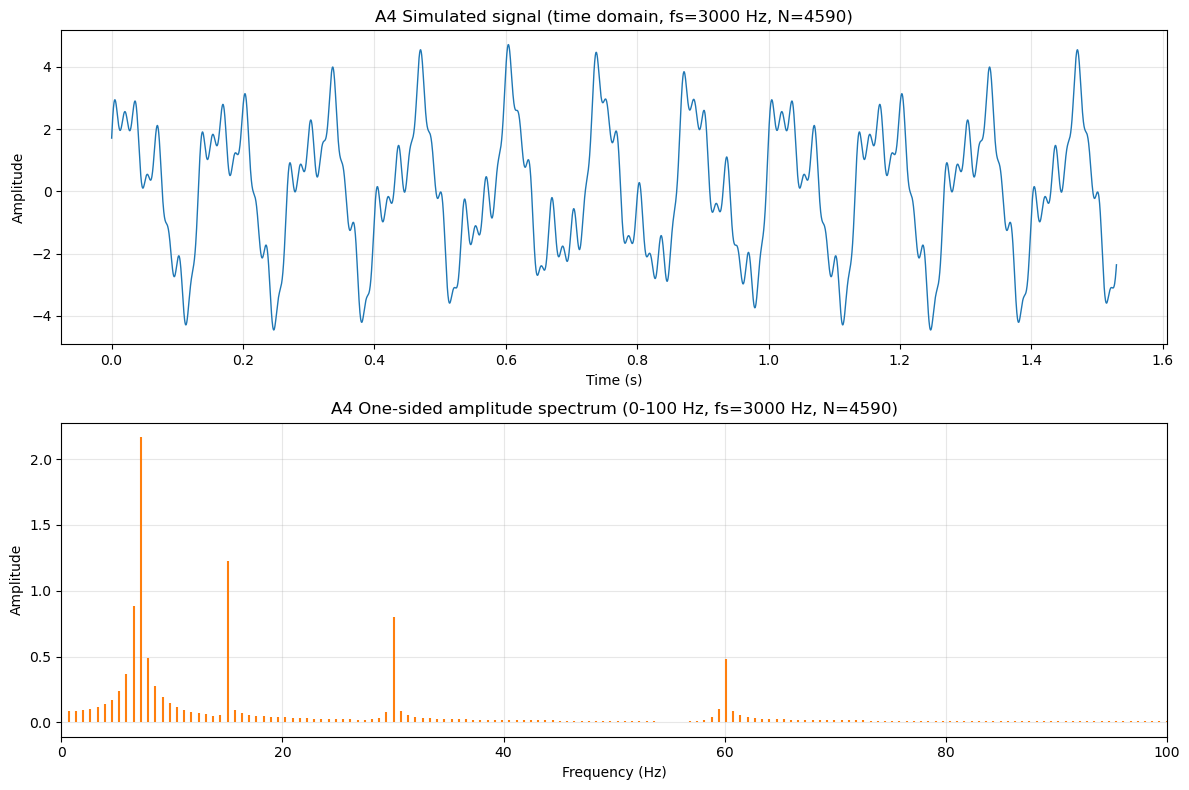

In [269]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result_a4["t"], x_sim_a4, color="tab:blue", linewidth=1.0)
axes[0].set_title(f"A4 Simulated signal (time domain, fs={fs_sim_a4} Hz, N={N_sim_a4})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result_a4["freqs"],
    sim_result_a4["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, 100)
axes[1].set_title(f"A4 One-sided amplitude spectrum (0-100 Hz, fs={fs_sim_a4} Hz, N={N_sim_a4})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

EDF file: EEG_DATA.edf
Sampling rate: 200.00 Hz
Channels: 24
Processing channel 1/24: Fp1
=== Channel 1 full-length DFT (Fp1) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



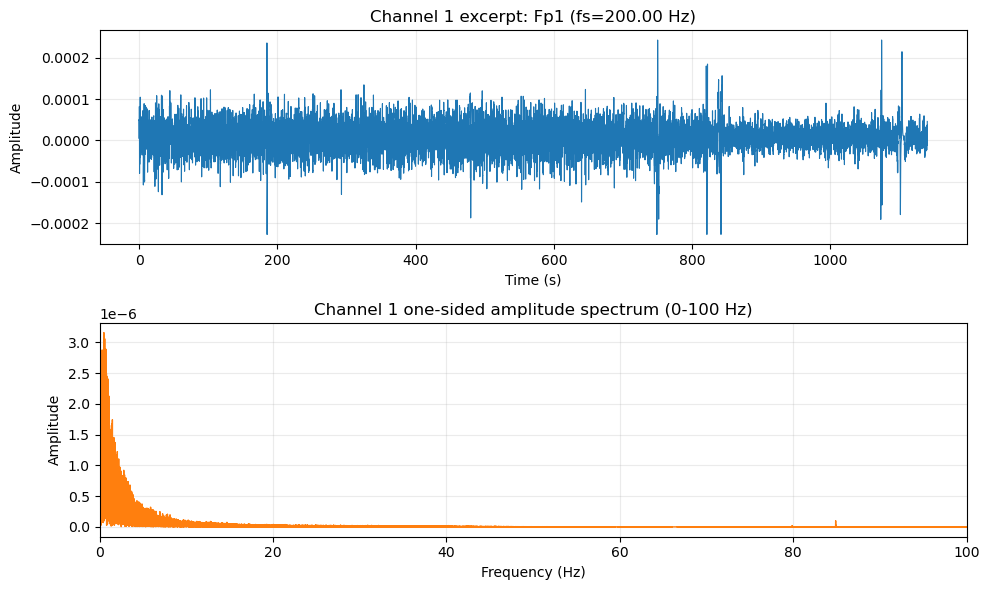

Processing channel 2/24: Fp2
=== Channel 2 full-length DFT (Fp2) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



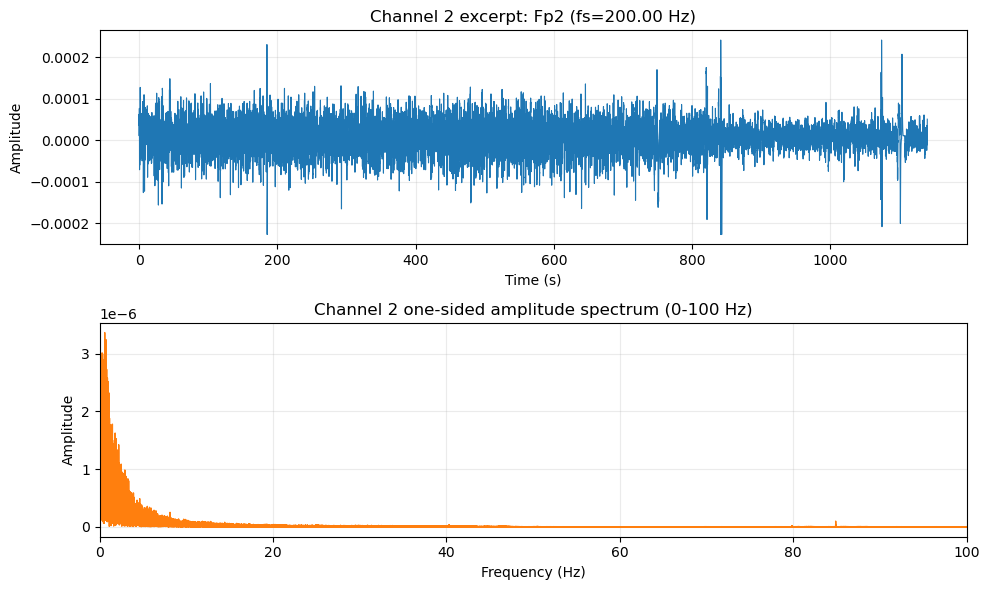

Processing channel 3/24: F3
=== Channel 3 full-length DFT (F3) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



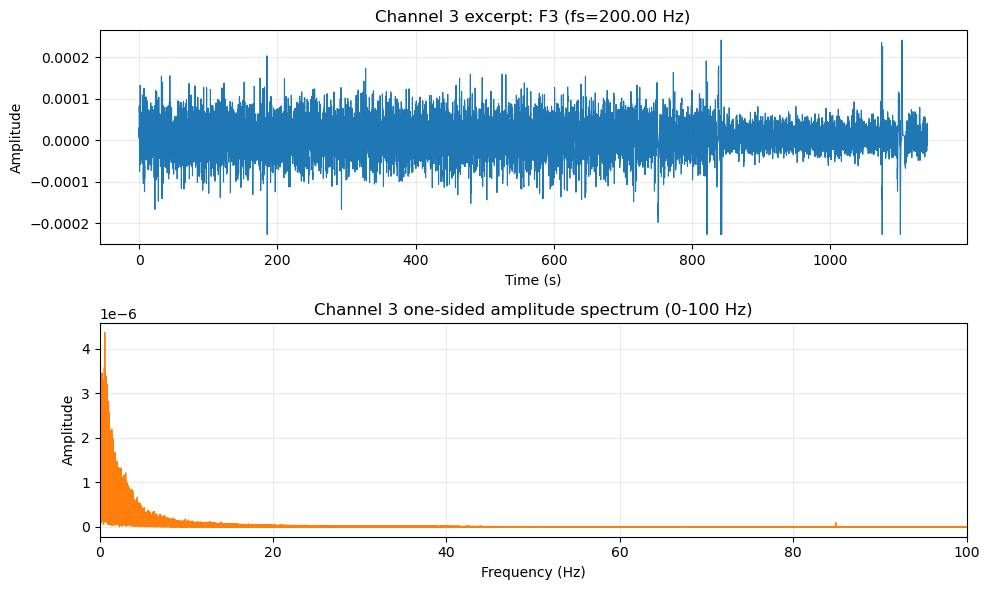

Processing channel 4/24: F4
=== Channel 4 full-length DFT (F4) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



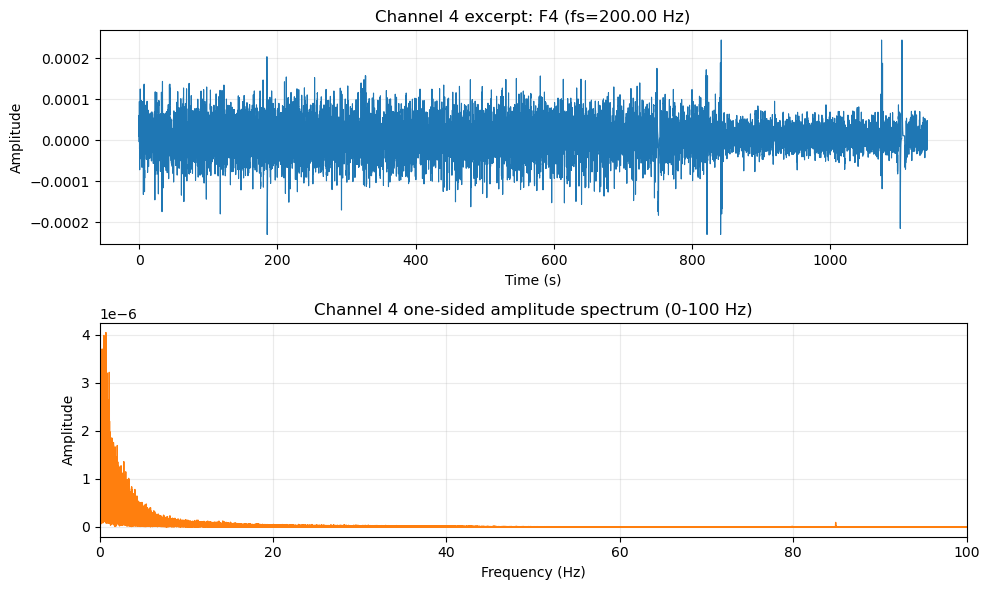

Processing channel 5/24: C3
=== Channel 5 full-length DFT (C3) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



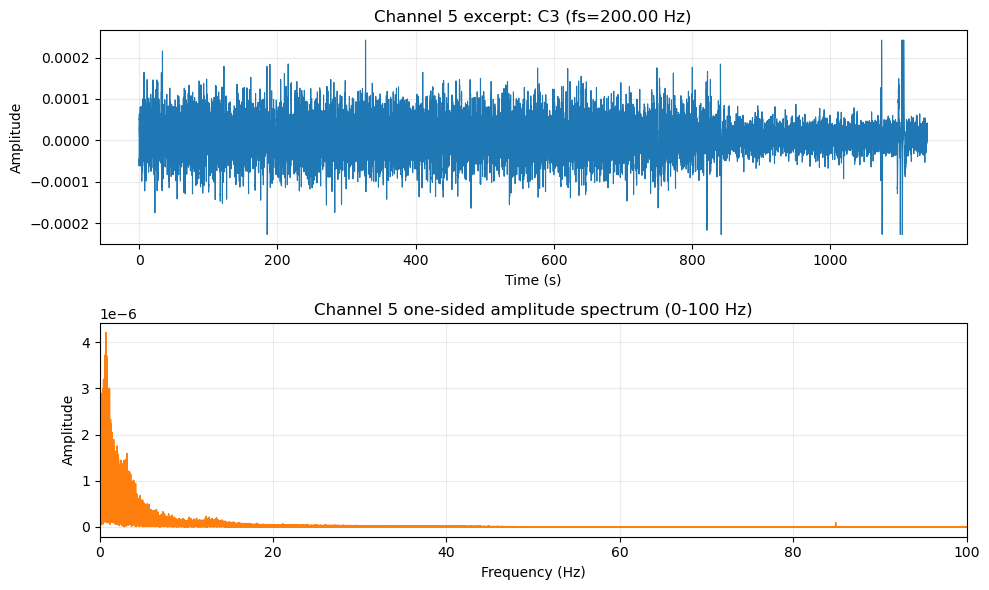

Processing channel 6/24: C4
=== Channel 6 full-length DFT (C4) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



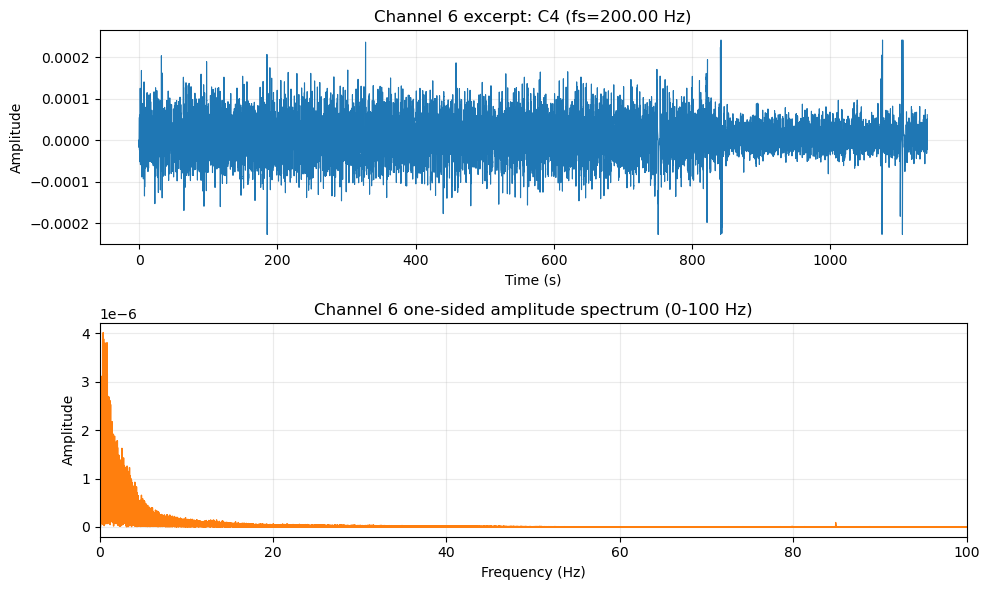

Processing channel 7/24: P3
=== Channel 7 full-length DFT (P3) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



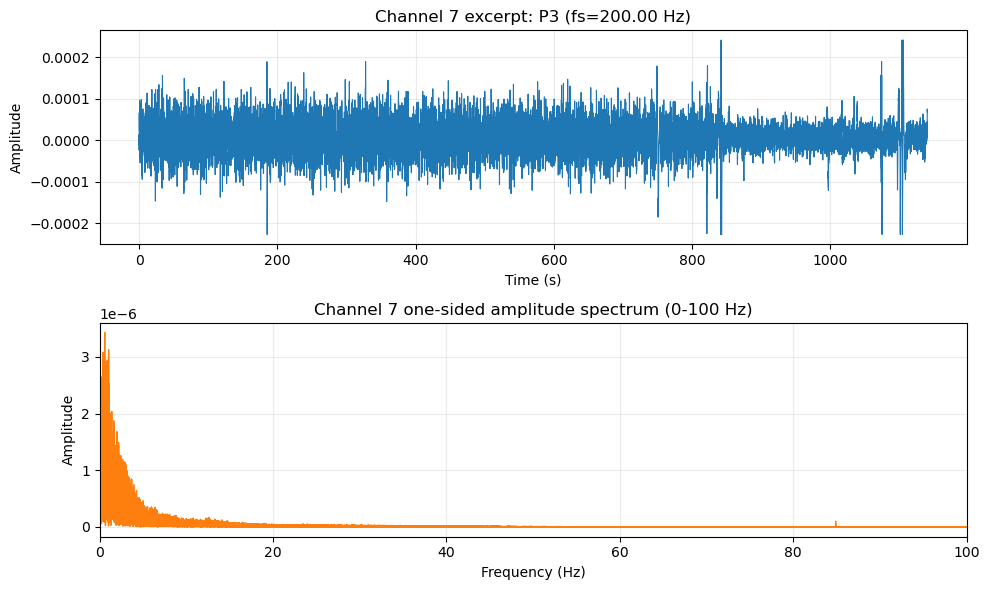

Processing channel 8/24: P4
=== Channel 8 full-length DFT (P4) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



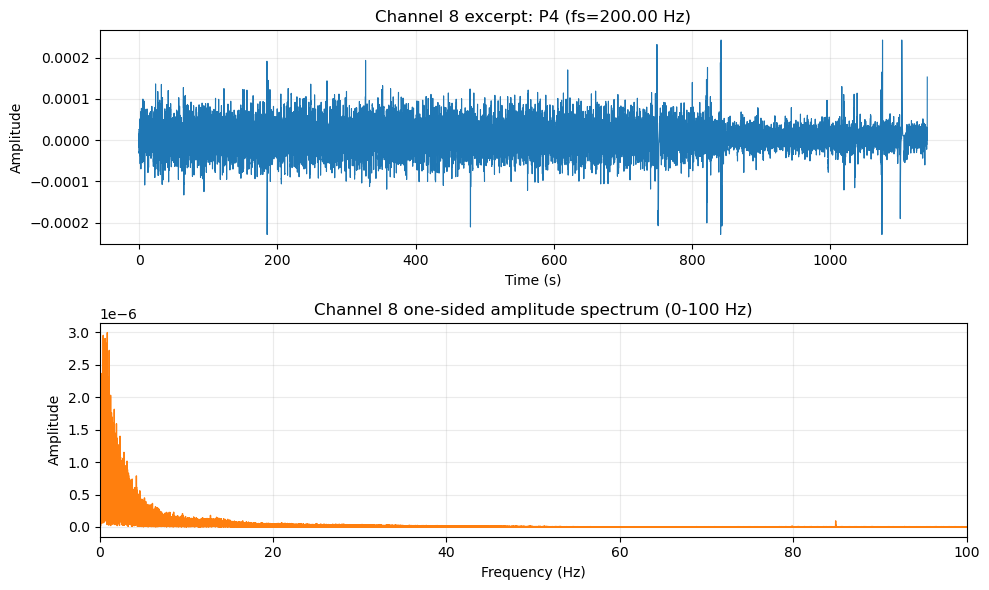

Processing channel 9/24: O1
=== Channel 9 full-length DFT (O1) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.897e-19



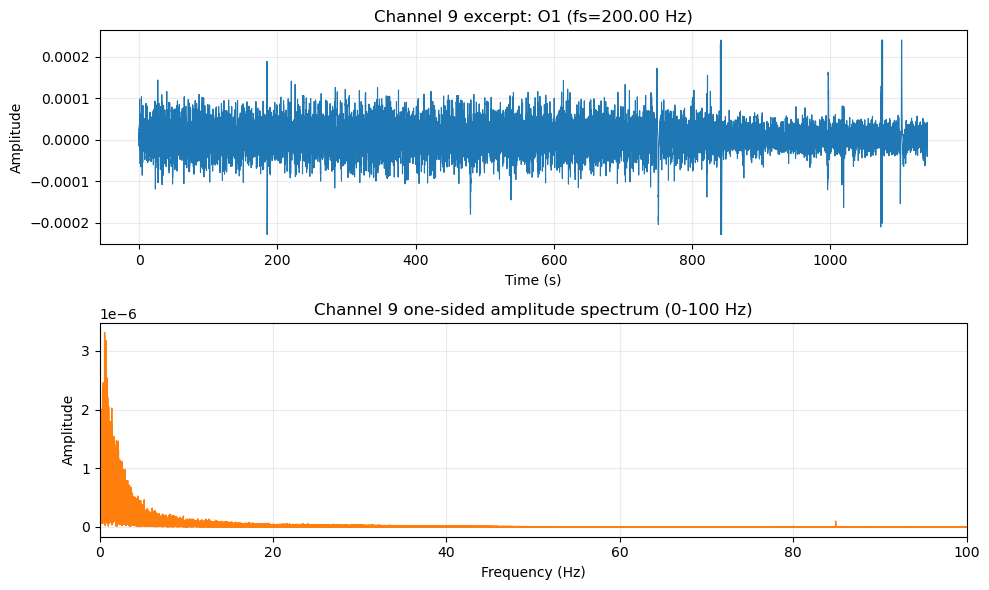

Processing channel 10/24: O2
=== Channel 10 full-length DFT (O2) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



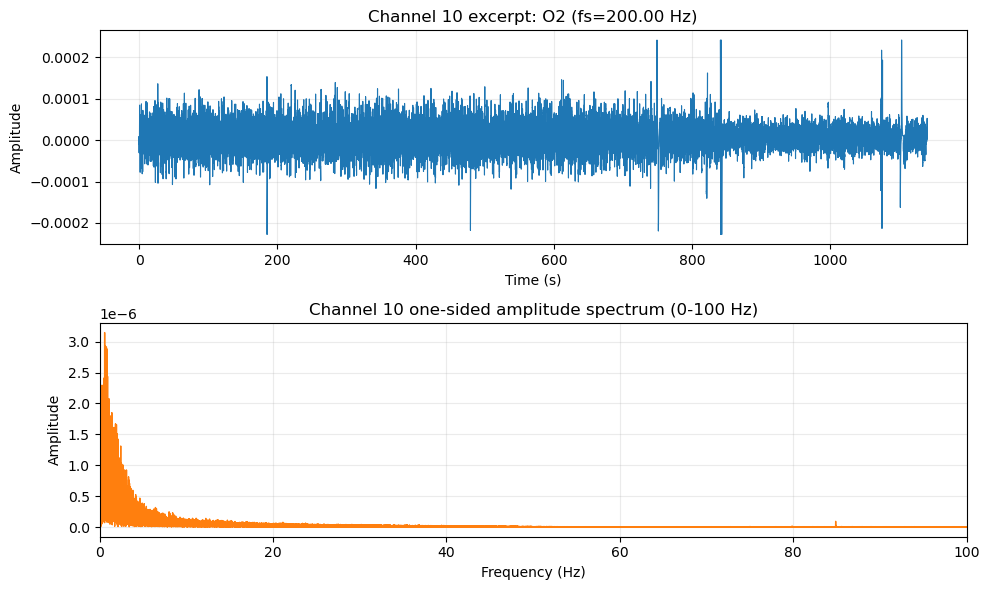

Processing channel 11/24: F7
=== Channel 11 full-length DFT (F7) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



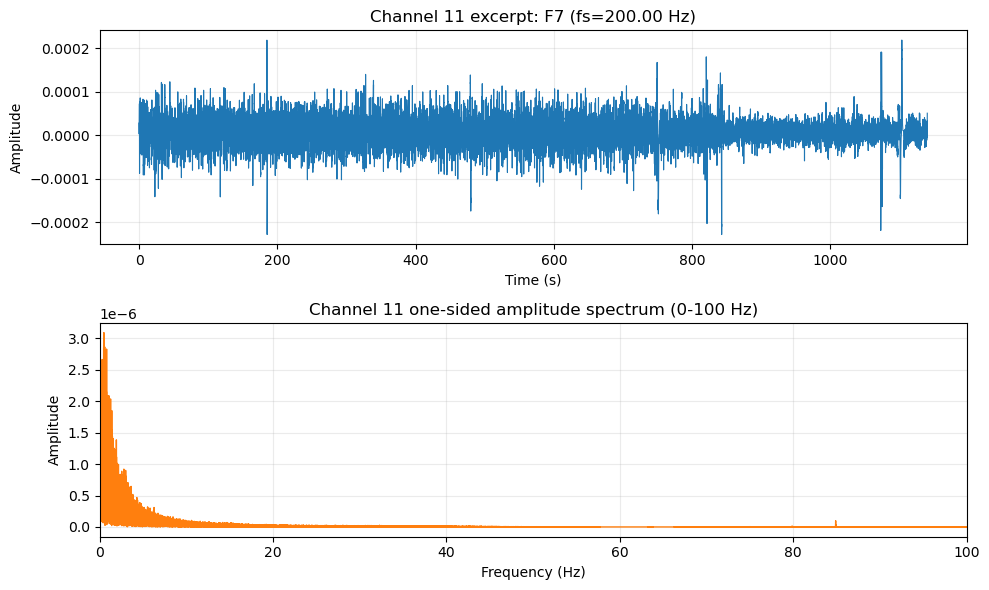

Processing channel 12/24: F8
=== Channel 12 full-length DFT (F8) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



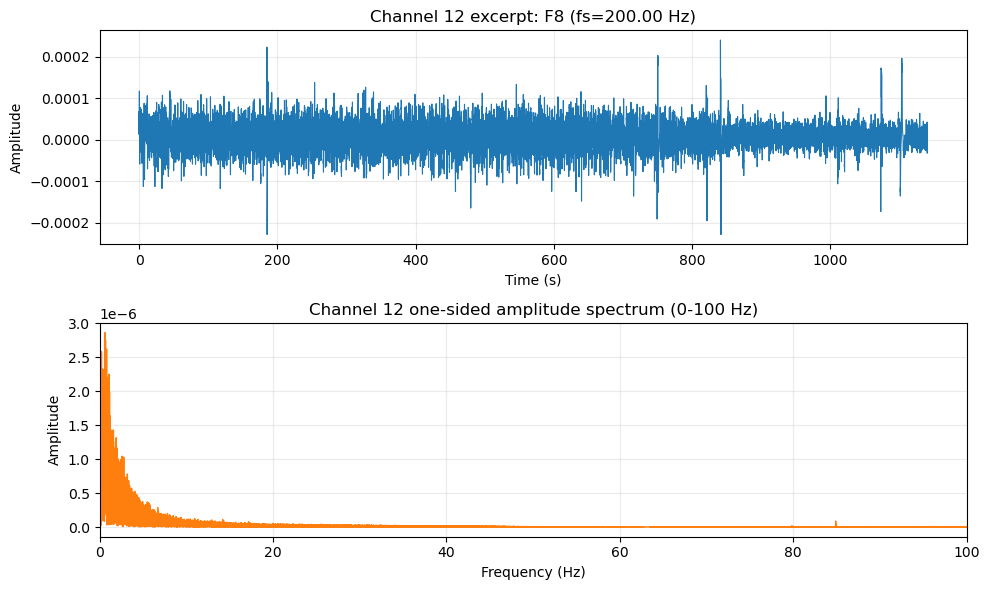

Processing channel 13/24: T3
=== Channel 13 full-length DFT (T3) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.897e-19



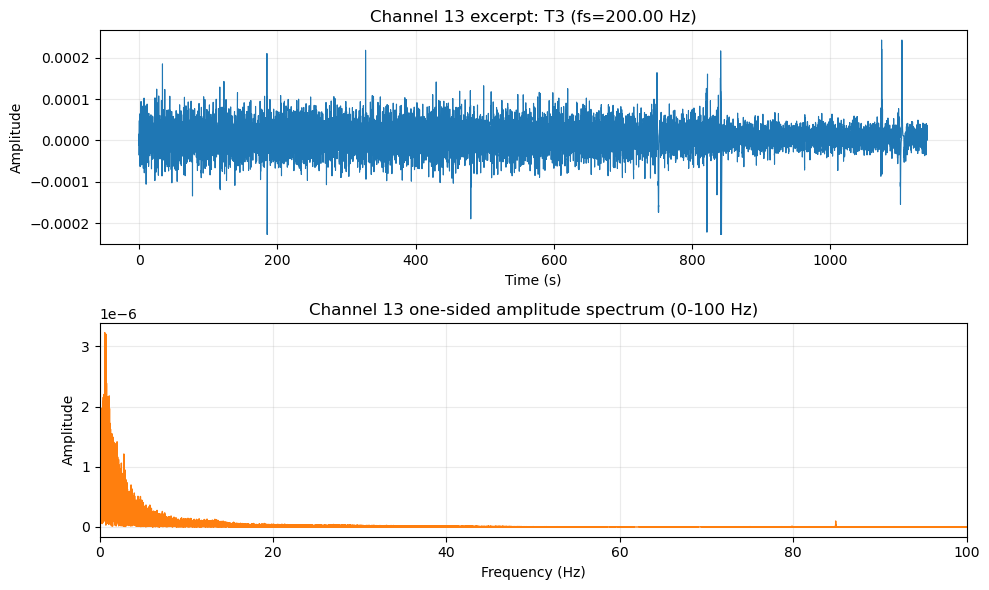

Processing channel 14/24: T4
=== Channel 14 full-length DFT (T4) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



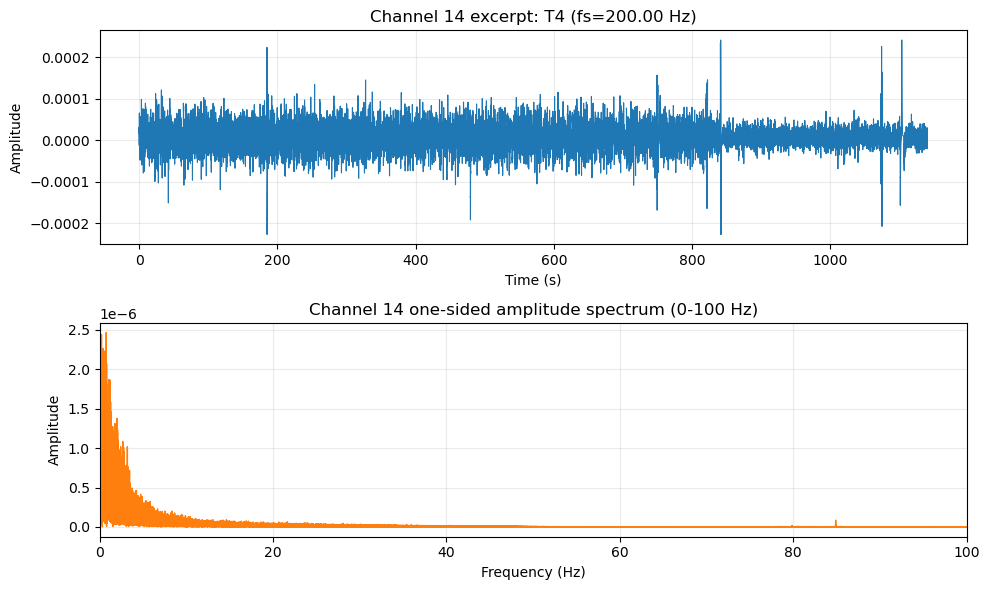

Processing channel 15/24: T5
=== Channel 15 full-length DFT (T5) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



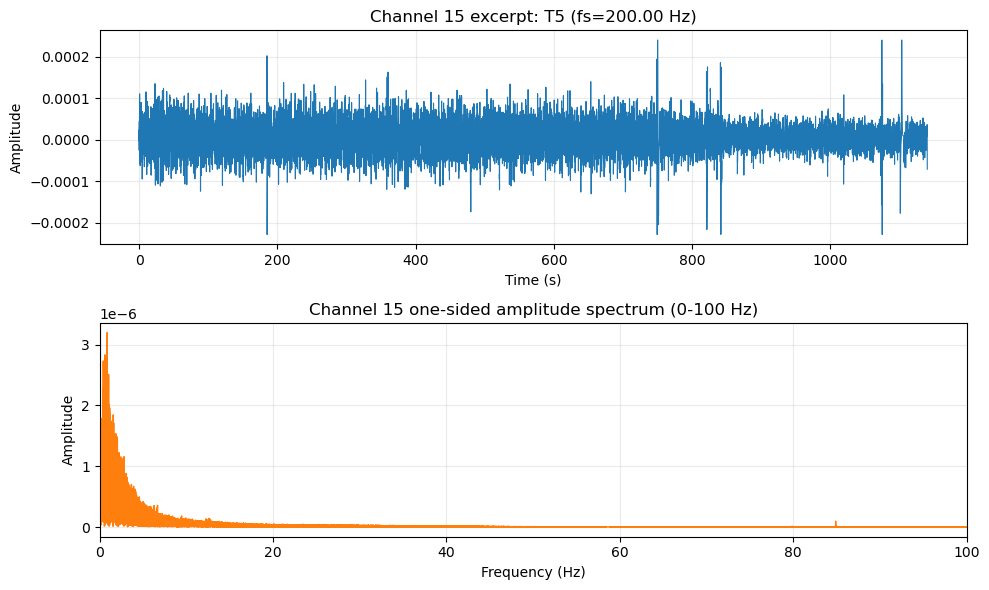

Processing channel 16/24: T6
=== Channel 16 full-length DFT (T6) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



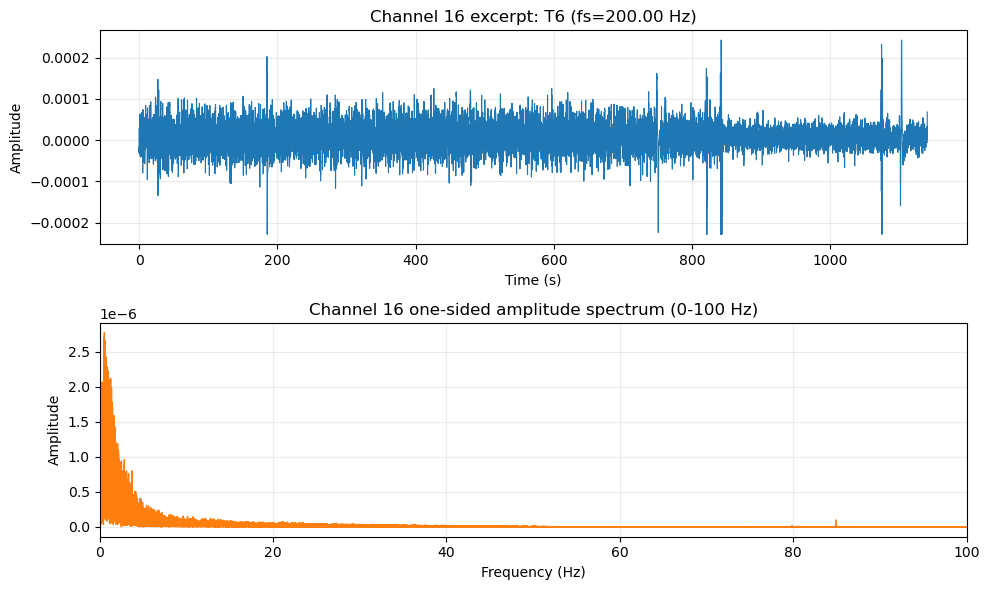

Processing channel 17/24: FZ
=== Channel 17 full-length DFT (FZ) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



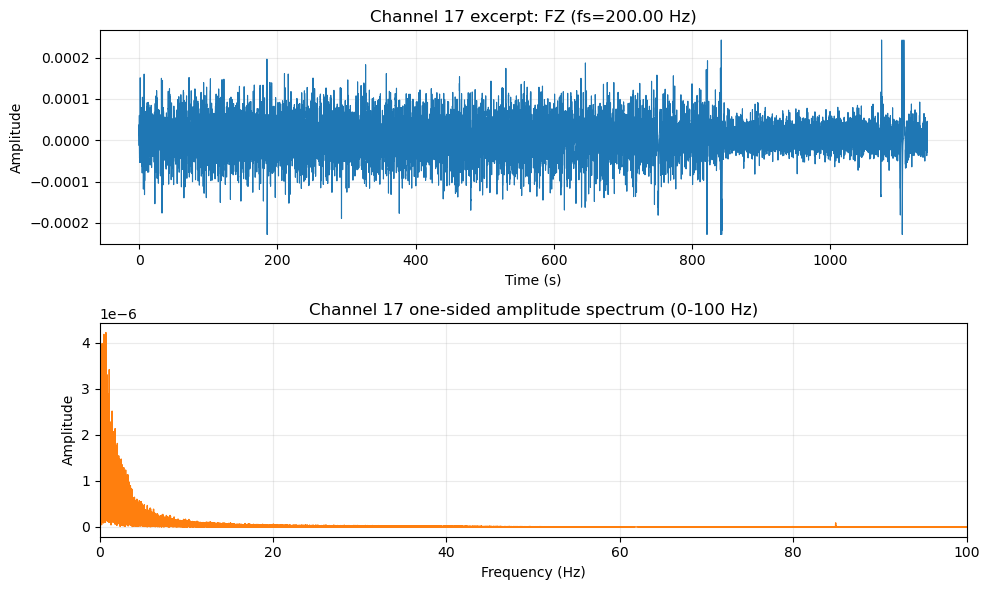

Processing channel 18/24: CZ
=== Channel 18 full-length DFT (CZ) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



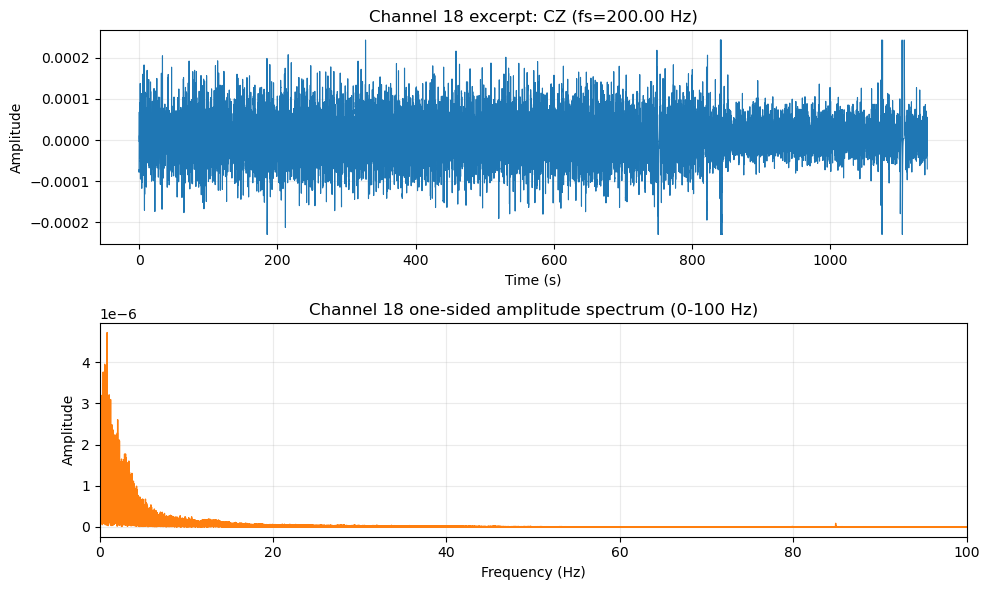

Processing channel 19/24: PZ
=== Channel 19 full-length DFT (PZ) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.897e-19



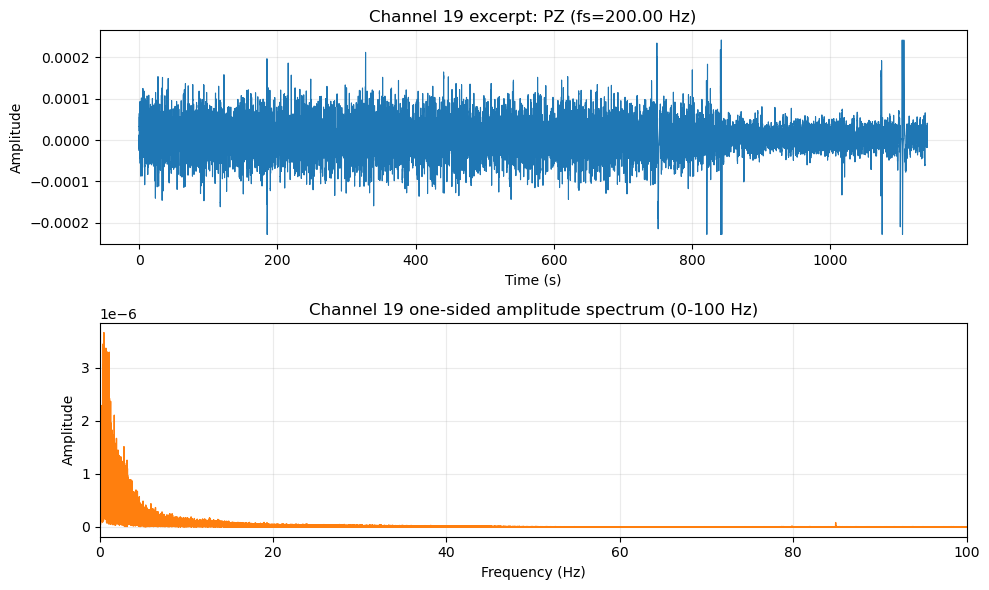

Processing channel 20/24: Pg1
=== Channel 20 full-length DFT (Pg1) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.626e-19



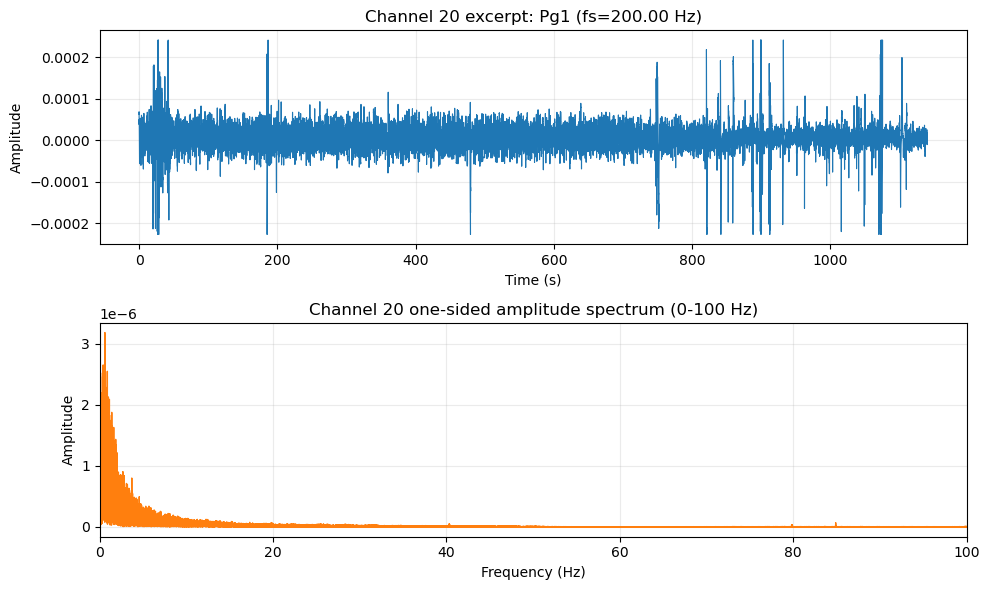

Processing channel 21/24: Pg2
=== Channel 21 full-length DFT (Pg2) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19



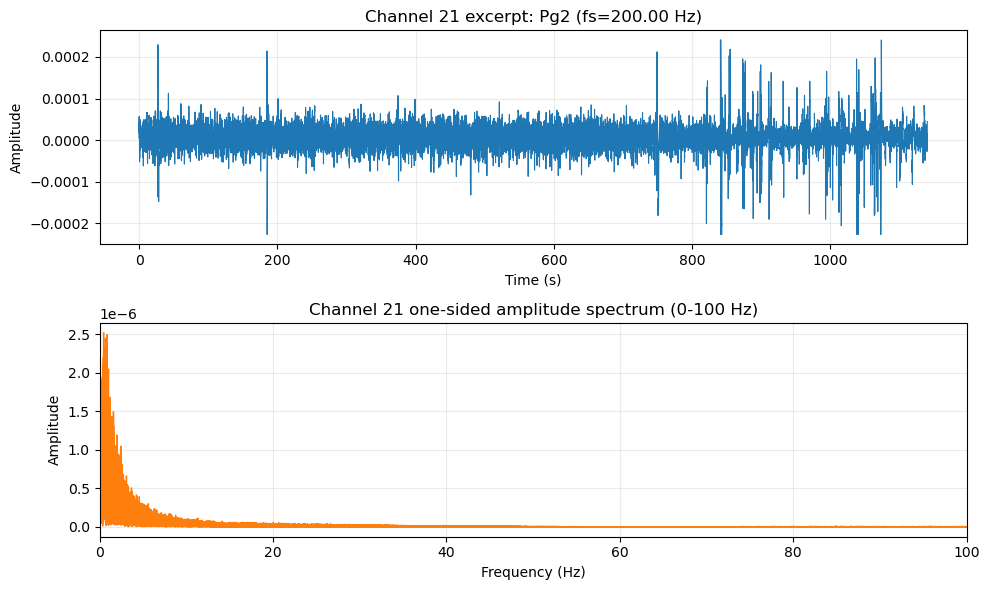

Processing channel 22/24: 25+
=== Channel 22 full-length DFT (25+) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 4.066e-20



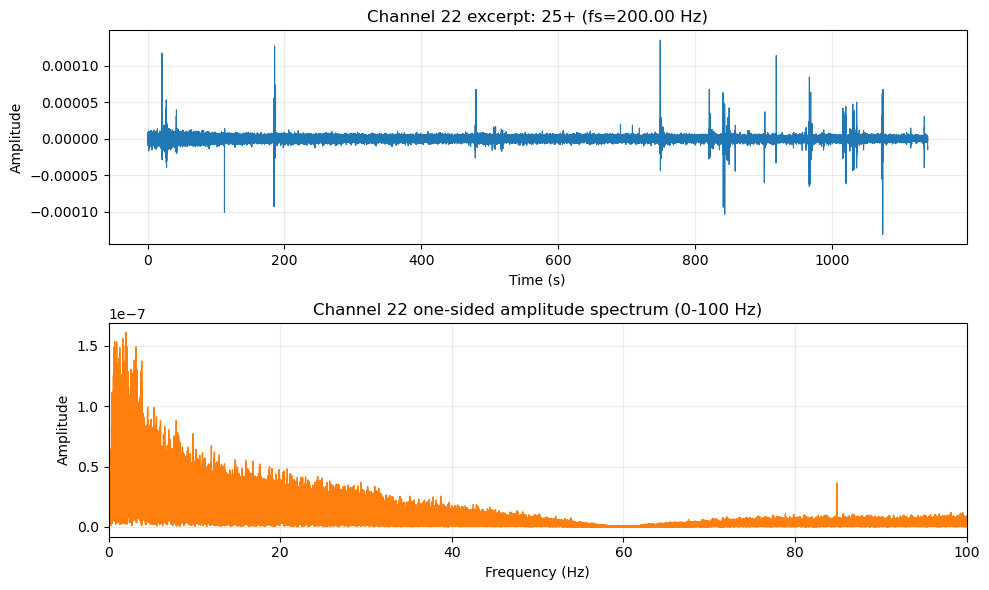

Processing channel 23/24: 26+
=== Channel 23 full-length DFT (26+) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 5.421e-20



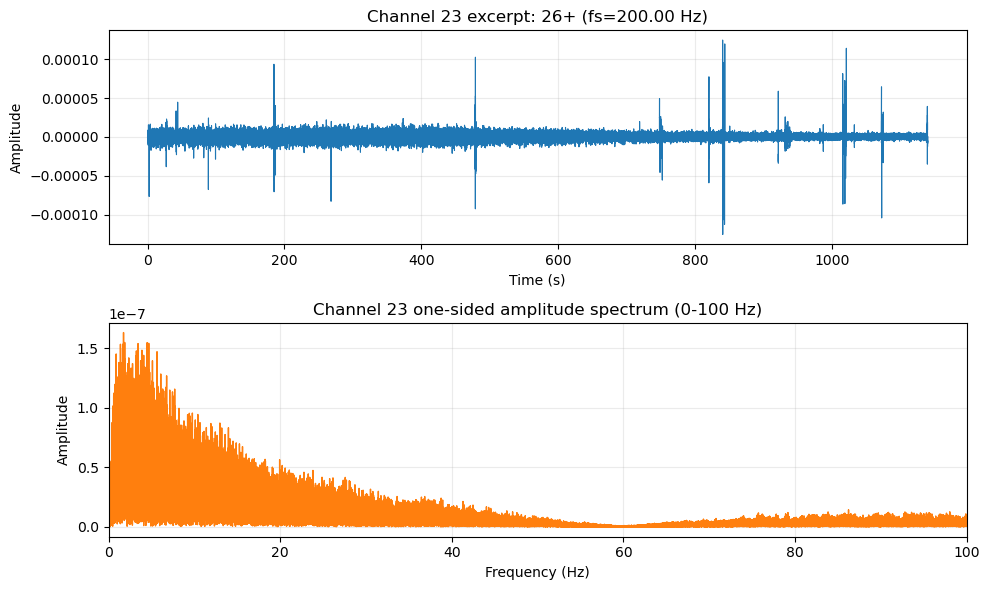

Processing channel 24/24: 27+
=== Channel 24 full-length DFT (27+) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 5.421e-20



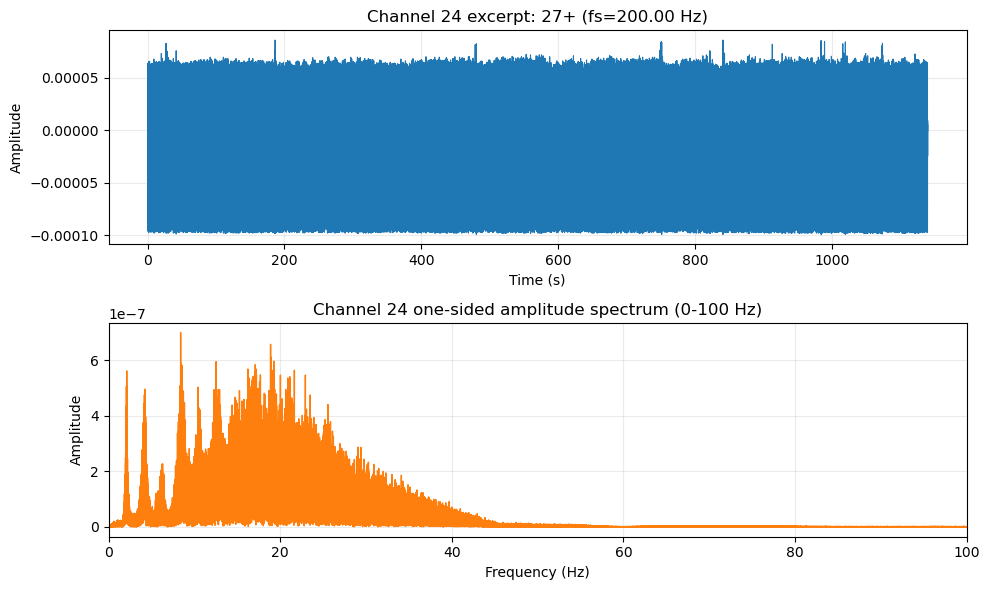

=== EEG selected channel full-length DFT (Fp1) ===
N = 228000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = -0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 1.355e-19

=== EEG selected channel DFT (Fp1) ===
N = 3000, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 0.000e+00
Max one-sided amplitude difference = 0.000e+00
Max IFFT reconstruction error = 6.776e-20



In [270]:
# Part B1: analyze the EEG EDF file and plot each channel individually, then select channel 1
import mne

edf_path = Path("/home/plutonium/Documents/Biosignals/project/notebooks/week1/data/EEG_DATA.edf")
raw_eeg = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
eeg_data = raw_eeg.get_data()
fs_real = float(raw_eeg.info["sfreq"])
channel_names = raw_eeg.ch_names
n_channels = len(channel_names)

print(f"EDF file: {edf_path.name}")
print(f"Sampling rate: {fs_real:.2f} Hz")
print(f"Channels: {n_channels}")

# Variables used by the stationarity comparison below (keep shape compatible).
epochs_reref = eeg_data[np.newaxis, :, :]
trial_idx = 0
channel_idx = 0

# Loop over channels: compute full-length DFT and show time excerpt + 0-100 Hz one-sided spectrum for each channel.
for ch_idx, ch_name in enumerate(channel_names):
    ch_signal = eeg_data[ch_idx].astype(float)
    print(f"Processing channel {ch_idx+1}/{n_channels}: {ch_name}")
    x_full_ch = ch_signal - np.mean(ch_signal)
    # use FFT for speed on full-length data
    ch_result = analyze_signal(x_full_ch, fs_real, f"Channel {ch_idx+1} full-length DFT ({ch_name})", use_manual_dtft=False)

    # Plot a short time excerpt and the 0-100 Hz one-sided amplitude spectrum for this channel.
    plot_seconds = min(3000, len(ch_signal) / fs_real)
    plot_len = max(1, int(plot_seconds * fs_real))
    time_ch = np.arange(plot_len) / fs_real

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    axes[0].plot(time_ch, ch_signal[:plot_len], color="tab:blue", linewidth=0.8)
    axes[0].set_title(f"Channel {ch_idx+1} excerpt: {ch_name} (fs={fs_real:.2f} Hz)")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(alpha=0.25)

    freq_limit = min(100, fs_real / 2)
    mask = ch_result['freqs'] <= freq_limit
    axes[1].plot(ch_result['freqs'][mask], ch_result['amp_fft'][mask], color="tab:orange", linewidth=1.0)
    axes[1].set_xlim(0, freq_limit)
    axes[1].set_title(f"Channel {ch_idx+1} one-sided amplitude spectrum (0-{freq_limit:.0f} Hz)")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

# After plotting all channels, select channel 1 (index 0) as the working channel for B2/B3/stationarity.
selected_idx = 0
first_channel_name = channel_names[selected_idx]
first_channel = eeg_data[selected_idx].astype(float)

# Analyze the selected (channel 1) full-length signal and keep a 1-second slice for stationarity comparison.
x_real_full = first_channel - np.mean(first_channel)
full_result = analyze_signal(x_real_full, fs_real, f"EEG selected channel full-length DFT ({first_channel_name})", use_manual_dtft=False)

window_len = max(3000, min(len(first_channel), int(round(fs_real))))
x_real = first_channel[:window_len] - np.mean(first_channel[:window_len])
real_result = analyze_signal(x_real, fs_real, f"EEG selected channel DFT ({first_channel_name})")


EEG amplitude-bin statistics (full-length one-sided spectrum)
Bins analyzed: 114001 (0 Hz to Nyquist)
Including DC: mean = 3.164679e-08, SD = 1.377147e-07, median = 2.744698e-09
  IQR = [1.521354e-09, 9.714647e-09]
Excluding DC: mean = 3.164707e-08, SD = 1.377153e-07, median = 2.744706e-09
  IQR = [1.521361e-09, 9.714718e-09]


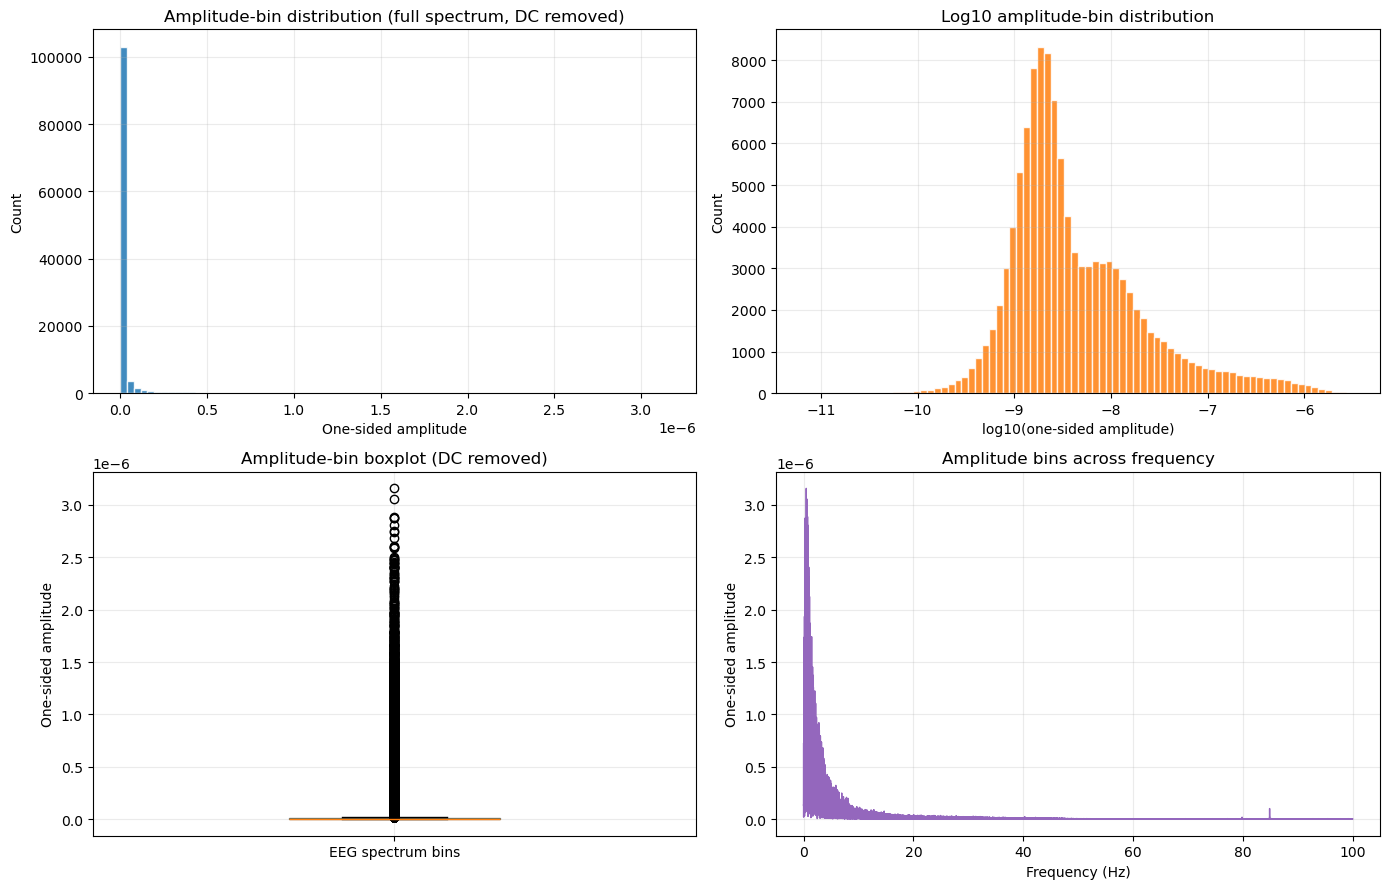

In [271]:
# Part B2: amplitude-bin statistics for the full-length EEG spectrum
amp_bins_full = full_result["amp_fft"]
freqs_bins_full = full_result["freqs"]

amp_bins_no_dc = amp_bins_full[1:]
freqs_bins_no_dc = freqs_bins_full[1:]

mean_all = float(np.mean(amp_bins_full))
std_all = float(np.std(amp_bins_full, ddof=1))
median_all = float(np.median(amp_bins_full))
q25_all, q75_all = np.percentile(amp_bins_full, [25, 75])

mean_no_dc = float(np.mean(amp_bins_no_dc))
std_no_dc = float(np.std(amp_bins_no_dc, ddof=1))
median_no_dc = float(np.median(amp_bins_no_dc))
q25_no_dc, q75_no_dc = np.percentile(amp_bins_no_dc, [25, 75])

print("EEG amplitude-bin statistics (full-length one-sided spectrum)")
print(f"Bins analyzed: {len(amp_bins_full)} (0 Hz to Nyquist)")
print(f"Including DC: mean = {mean_all:.6e}, SD = {std_all:.6e}, median = {median_all:.6e}")
print(f"  IQR = [{q25_all:.6e}, {q75_all:.6e}]")
print(f"Excluding DC: mean = {mean_no_dc:.6e}, SD = {std_no_dc:.6e}, median = {median_no_dc:.6e}")
print(f"  IQR = [{q25_no_dc:.6e}, {q75_no_dc:.6e}]")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(amp_bins_no_dc, bins=80, color="tab:blue", alpha=0.85, edgecolor="white")
axes[0, 0].set_title("Amplitude-bin distribution (full spectrum, DC removed)")
axes[0, 0].set_xlabel("One-sided amplitude")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.25)

axes[0, 1].hist(np.log10(amp_bins_no_dc + 1e-20), bins=80, color="tab:orange", alpha=0.85, edgecolor="white")
axes[0, 1].set_title("Log10 amplitude-bin distribution")
axes[0, 1].set_xlabel("log10(one-sided amplitude)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.25)

axes[1, 0].boxplot(
    amp_bins_no_dc,
    vert=True,
    widths=0.35,
    patch_artist=True,
    boxprops=dict(facecolor="tab:green", alpha=0.5),
)
axes[1, 0].set_title("Amplitude-bin boxplot (DC removed)")
axes[1, 0].set_ylabel("One-sided amplitude")
axes[1, 0].set_xticks([1])
axes[1, 0].set_xticklabels(["EEG spectrum bins"])
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(freqs_bins_no_dc, amp_bins_no_dc, color="tab:purple", linewidth=1.0)
axes[1, 1].set_title("Amplitude bins across frequency")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("One-sided amplitude")
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


Noise-floor estimation for the full-length EEG spectrum
Method 1: threshold = median(|X|) + 2*MAD(|X|) = 6.212254e-09
  Signal candidates: 37167, noise-floor bins: 76833
  SNR = 20log10(signal/noise) = 32.64 dB
Method 2: visual cutoff = log10 amplitude >= -8.5
  Signal candidates: 51810, noise-floor bins: 62190
  SNR = 20log10(signal/noise) = 32.32 dB
Log10 amplitude range (non-DC): median = -8.562, IQR = [-8.818, -8.013]


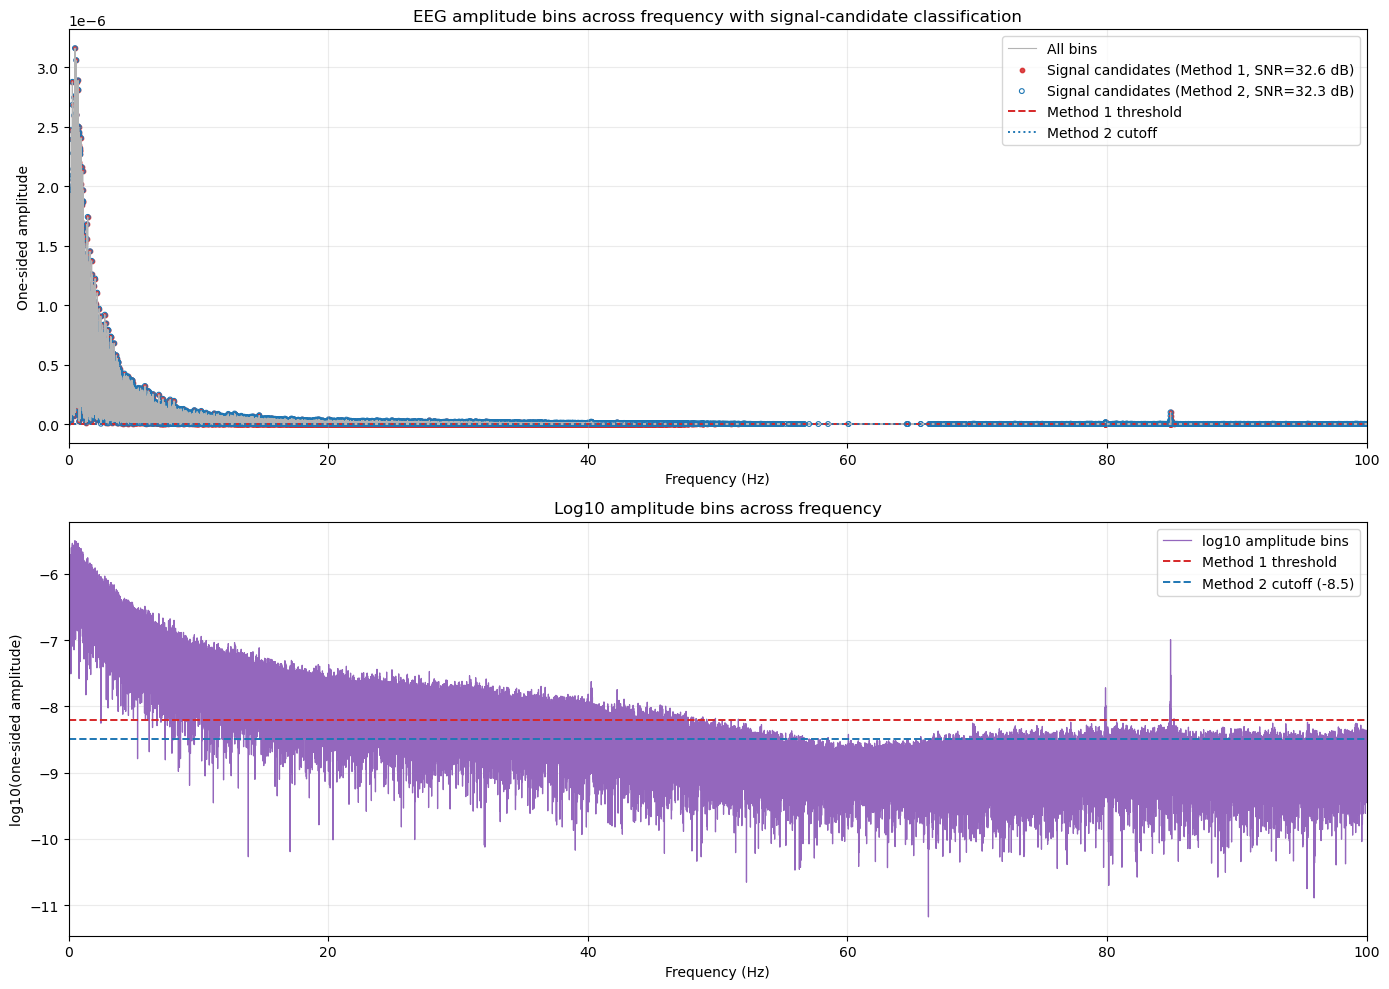

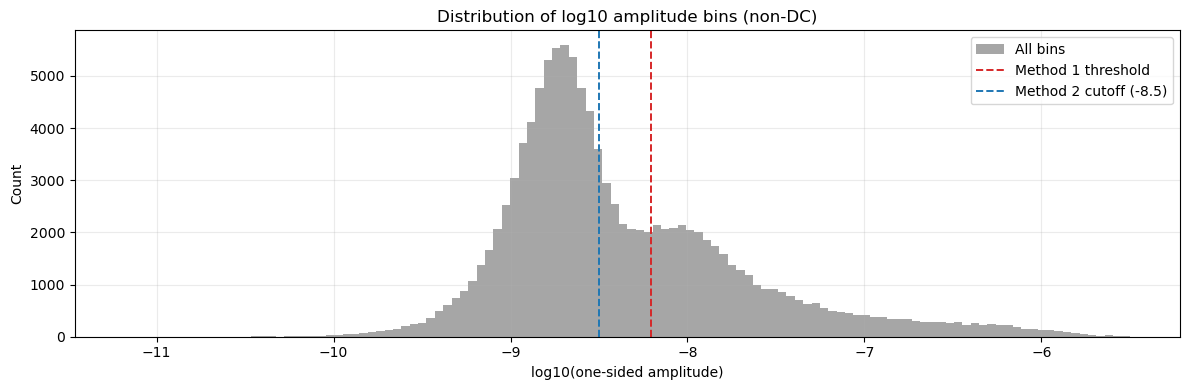

In [272]:
# Part B3: noise-floor estimation and signal-candidate bin classification
amp_bins = full_result["amp_fft"]
freq_bins = full_result["freqs"]

# Method 1: robust threshold from median + 2 * MAD in linear amplitude space.
median_amp = float(np.median(amp_bins))
mad_amp = float(np.median(np.abs(amp_bins - median_amp)))
threshold_m1 = median_amp + 2.0 * mad_amp

# Method 2: visual inspection cutoff at log10 amplitude = -8.5.
log10_threshold_m2 = -8.5
threshold_m2 = 10 ** log10_threshold_m2

# Classify bins.
signal_mask_m1 = amp_bins > threshold_m1
noise_mask_m1 = ~signal_mask_m1
signal_mask_m2 = np.log10(amp_bins + 1e-30) >= log10_threshold_m2
noise_mask_m2 = ~signal_mask_m2

# Focus on non-DC bins for summary counts, but keep DC in the plots.
non_dc = np.arange(len(amp_bins)) > 0

count_signal_m1 = int(np.sum(signal_mask_m1 & non_dc))
count_noise_m1 = int(np.sum(noise_mask_m1 & non_dc))
count_signal_m2 = int(np.sum(signal_mask_m2 & non_dc))
count_noise_m2 = int(np.sum(noise_mask_m2 & non_dc))

# SNR by signal/noise amplitude ratio in dB using the bins selected by each method.
def snr_db(signal_mask):
    signal_bins = amp_bins[signal_mask & non_dc]
    noise_bins = amp_bins[(~signal_mask) & non_dc]
    signal_level = float(np.mean(signal_bins))
    noise_level = float(np.mean(noise_bins))
    return 20.0 * np.log10((signal_level + 1e-30) / (noise_level + 1e-30)), signal_level, noise_level

snr_m1_db, signal_level_m1, noise_level_m1 = snr_db(signal_mask_m1)
snr_m2_db, signal_level_m2, noise_level_m2 = snr_db(signal_mask_m2)

print("Noise-floor estimation for the full-length EEG spectrum")
print(f"Method 1: threshold = median(|X|) + 2*MAD(|X|) = {threshold_m1:.6e}")
print(f"  Signal candidates: {count_signal_m1}, noise-floor bins: {count_noise_m1}")
print(f"  SNR = 20log10(signal/noise) = {snr_m1_db:.2f} dB")
print(f"Method 2: visual cutoff = log10 amplitude >= {log10_threshold_m2:.1f}")
print(f"  Signal candidates: {count_signal_m2}, noise-floor bins: {count_noise_m2}")
print(f"  SNR = 20log10(signal/noise) = {snr_m2_db:.2f} dB")

# Helpful distribution diagnostics in log10 space.
log_amp = np.log10(amp_bins[non_dc] + 1e-30)
log_median = float(np.median(log_amp))
log_q25, log_q75 = np.percentile(log_amp, [25, 75])
print(f"Log10 amplitude range (non-DC): median = {log_median:.3f}, IQR = [{log_q25:.3f}, {log_q75:.3f}]")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Spectrum view with thresholds and highlighted candidates.
axes[0].plot(freq_bins, amp_bins, color="0.7", linewidth=0.8, label="All bins")
axes[0].scatter(
    freq_bins[signal_mask_m1],
    amp_bins[signal_mask_m1],
    s=10,
    color="tab:red",
    alpha=0.85,
    label=f"Signal candidates (Method 1, SNR={snr_m1_db:.1f} dB)",
)
axes[0].scatter(
    freq_bins[signal_mask_m2],
    amp_bins[signal_mask_m2],
    s=12,
    facecolors="none",
    edgecolors="tab:blue",
    linewidths=0.8,
    label=f"Signal candidates (Method 2, SNR={snr_m2_db:.1f} dB)",
)
axes[0].axhline(threshold_m1, color="tab:red", linestyle="--", linewidth=1.4, label="Method 1 threshold")
axes[0].axhline(threshold_m2, color="tab:blue", linestyle=":", linewidth=1.4, label="Method 2 cutoff")
axes[0].set_xlim(0, min(100, fs_real / 2))
axes[0].set_title("EEG amplitude bins across frequency with signal-candidate classification")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("One-sided amplitude")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper right")

# Log-scale distribution view with Method 1 and Method 2 visual cutoff.
axes[1].plot(freq_bins[non_dc], log_amp, color="tab:purple", linewidth=0.9, label="log10 amplitude bins")
axes[1].axhline(np.log10(threshold_m1), color="tab:red", linestyle="--", linewidth=1.4, label="Method 1 threshold")
axes[1].axhline(log10_threshold_m2, color="tab:blue", linestyle="--", linewidth=1.4, label="Method 2 cutoff (-8.5)")
axes[1].set_xlim(0, min(100, fs_real / 2))
axes[1].set_title("Log10 amplitude bins across frequency")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("log10(one-sided amplitude)")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# Optional compact distribution chart for the classified bins.
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(log_amp, bins=120, color="0.5", alpha=0.7, label="All bins")
ax.axvline(np.log10(threshold_m1), color="tab:red", linestyle="--", linewidth=1.4, label="Method 1 threshold")
ax.axvline(log10_threshold_m2, color="tab:blue", linestyle="--", linewidth=1.4, label="Method 2 cutoff (-8.5)")
ax.set_title("Distribution of log10 amplitude bins (non-DC)")
ax.set_xlabel("log10(one-sided amplitude)")
ax.set_ylabel("Count")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Line-by-Line Concept Walkthrough (Chapter 11 Mapping)

1. `manual_dtft` function
- `N = len(x)` sets the number of samples and therefore frequency-bin spacing $\Delta f = f_s/N$.
- `for k in range(N)` loops over discrete frequencies (the DTFT/DFT frequency bins).
- `np.exp(-1j * 2 * np.pi * k * n / N)` is Euler's formula in computational form, creating a complex sine wave basis for each $k$.
- `X[k] = np.sum(x * complex_sine)` is the dot product: it measures how strongly the signal matches that frequency.
- `k=0` gives `exp(0)=1`, so `X[0]` is the DC component (sum/mean-related offset).

2. `one_sided_amplitude` function
- `np.abs(X)/N` converts complex coefficients to amplitude and normalizes by sample count.
- `N//2 + 1` keeps only unique positive frequencies from 0 Hz to Nyquist.
- Doubling non-DC/non-Nyquist bins preserves total energy in one-sided form.
- This scaling makes spectral peaks approximately match sine-wave amplitudes in time domain.

3. `analyze_signal` function
- Computes manual DTFT and NumPy FFT on the same signal.
- `max |DTFT - FFT|` verifies mathematical equivalence (differences should be near machine precision).
- `ifft(fft(x))` reconstructs the original signal, confirming no information loss in Fourier coefficients.
- Reconstruction error near zero validates inverse-transform correctness.

4. Simulated EEG section
- Signal is built as sum of 7, 15, and 30 Hz sinusoids plus random noise.
- This models the principle that complex signals are mixtures of simpler waves.
- Spectrum peaks should appear near those component frequencies.

5. Preprocessed EEG section
- Loads exported data from preprocessing workflow, ensuring realistic EEG context.
- A 1-second segment is used so manual DTFT remains tractable ($O(N^2)$).
- Same DTFT/FFT/IFFT checks are run to confirm theory holds on real data too.

6. Nyquist and stationarity notes
- Nyquist frequency is $f_s/2$, the highest resolvable frequency without aliasing.
- FFT here assumes segment-level stationarity (frequency content stable within analyzed window).
- EEG is often nonstationary over longer periods, motivating time-localized methods (STFT/wavelets).

7. Convolution theorem relevance
- In practice, FFT is also used for fast filtering because convolution in time equals multiplication in frequency.
- This is a major reason FFT is central to EEG preprocessing and analysis pipelines.

## Part C: Stationarity Example (1-Second Window vs Full EEG Segment)

A stationary signal should have similar frequency content over time. EEG is often nonstationary, so a short window can look very different from a long segment average.

In this example we compare:
- A 1-second EEG window (`x_real`)
- A full trial segment from the same channel

If the spectra are very different, that is evidence against strict stationarity.

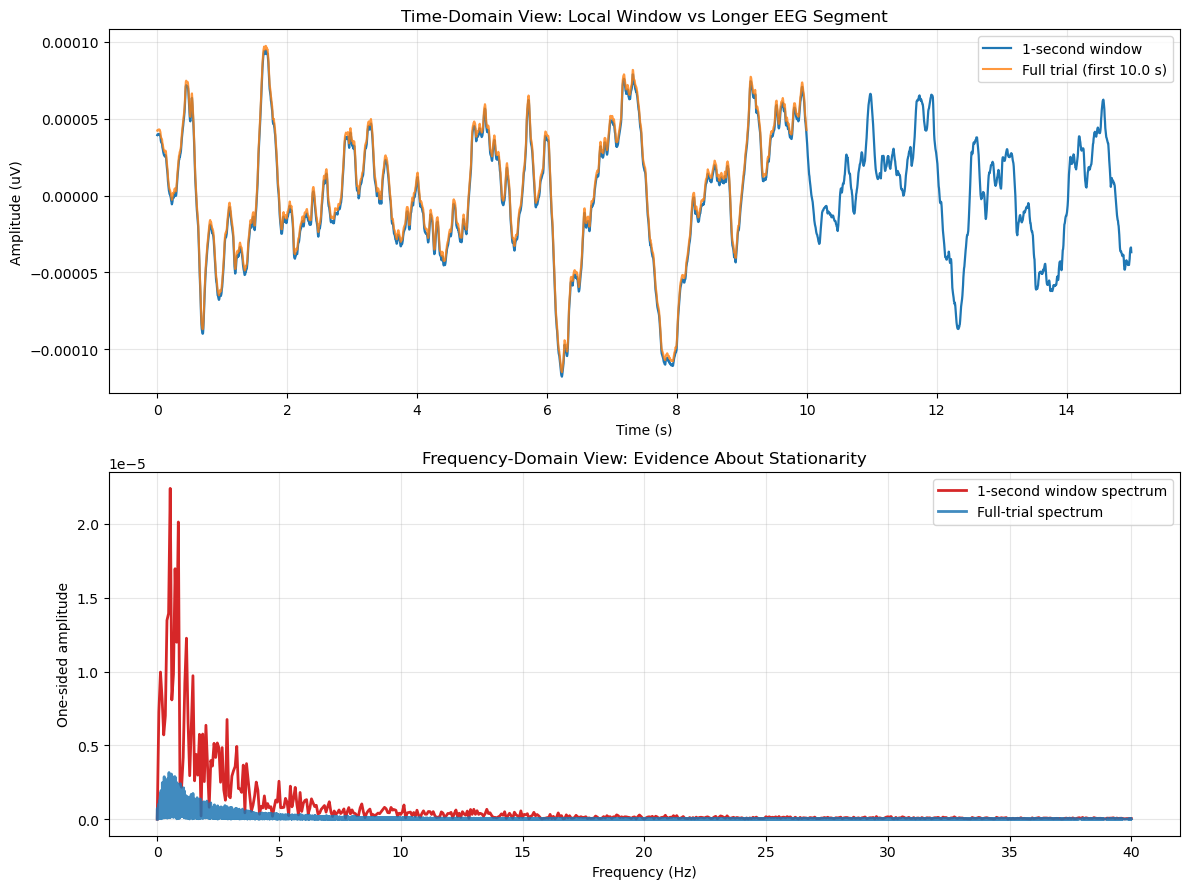

Stationarity comparison metrics:
  Relative L2 spectral difference (1 s vs full): 9.286
  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), 1 s window: 39.537
  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), full trial: 51.416

Interpretation:
  If these metrics differ substantially, the EEG is not strictly stationary across the trial.


In [273]:
# Compare stationarity: 1-second window vs full EEG trial segment
x_full = epochs_reref[trial_idx, channel_idx, :]
x_full = x_full - np.mean(x_full)

N_full = len(x_full)
freqs_full = np.arange(N_full // 2 + 1) * fs_real / N_full
X_full = np.fft.fft(x_full)
amp_full = one_sided_amplitude(X_full, N_full)

# Use same frequency range as the 1-second example for visual comparison
fmax_plot = 40
idx_1s = real_result["freqs"] <= fmax_plot
idx_full = freqs_full <= fmax_plot

# Interpolate full-segment spectrum onto 1-second frequency grid for a simple difference metric
amp_full_interp = np.interp(real_result["freqs"], freqs_full, amp_full)
l2_rel_diff = np.linalg.norm(real_result["amp_fft"] - amp_full_interp) / np.linalg.norm(amp_full_interp)

# Bandpower ratio example: low-frequency dominance can shift across windows
def bandpower(freqs, amp, f_lo, f_hi):
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return np.sum(amp[mask] ** 2)

bp_1s_low = bandpower(real_result["freqs"], real_result["amp_fft"], 1, 8)
bp_1s_high = bandpower(real_result["freqs"], real_result["amp_fft"], 8, 30)
bp_full_low = bandpower(freqs_full, amp_full, 1, 8)
bp_full_high = bandpower(freqs_full, amp_full, 8, 30)

ratio_1s = bp_1s_low / (bp_1s_high + 1e-12)
ratio_full = bp_full_low / (bp_full_high + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Time-domain comparison (1 s vs first 10 s of full trial)
plot_seconds = min(10.0, N_full / fs_real)
plot_len = int(plot_seconds * fs_real)
time_1s = np.arange(len(x_real)) / fs_real
time_full = np.arange(plot_len) / fs_real

axes[0].plot(time_1s, x_real, label="1-second window", linewidth=1.6)
axes[0].plot(time_full, x_full[:plot_len], label=f"Full trial (first {plot_seconds:.1f} s)", alpha=0.8)
axes[0].set_title("Time-Domain View: Local Window vs Longer EEG Segment")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (uV)")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right")

# Frequency-domain comparison
axes[1].plot(
    real_result["freqs"][idx_1s],
    real_result["amp_fft"][idx_1s],
    label="1-second window spectrum",
    linewidth=2,
    color="tab:red",
)
axes[1].plot(
    freqs_full[idx_full],
    amp_full[idx_full],
    label="Full-trial spectrum",
    linewidth=2,
    color="tab:blue",
    alpha=0.85,
)
axes[1].set_title("Frequency-Domain View: Evidence About Stationarity")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("One-sided amplitude")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("Stationarity comparison metrics:")
print(f"  Relative L2 spectral difference (1 s vs full): {l2_rel_diff:.3f}")
print(f"  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), 1 s window: {ratio_1s:.3f}")
print(f"  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), full trial: {ratio_full:.3f}")
print()
print("Interpretation:")
print("  If these metrics differ substantially, the EEG is not strictly stationary across the trial.")